## 1. Import Library yang Dibutuhkan

Import semua library yang diperlukan untuk analisis data, visualisasi, preprocessing, modeling, dan evaluasi.

In [2]:
# ============================================
# Import Library
# ============================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Model
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Cross Validation + Hyperparameter Tuning
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Statistical Test
from scipy.stats import ttest_rel

# Collections
from collections import Counter

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


## 2. Load dan Eksplorasi Dataset

Load dataset pinjaman dan lakukan eksplorasi awal untuk memahami struktur data, tipe data, dan informasi umum dataset.

In [4]:
# ============================================
# Load Dataset
# ============================================
df = pd.read_csv('data/loan_data.csv')

print("=" * 60)
print("INFORMASI UMUM DATASET")
print("=" * 60)
print(f"Jumlah Baris   : {df.shape[0]:,}")
print(f"Jumlah Kolom   : {df.shape[1]}")
print(f"Ukuran Dataset : {df.shape[0] * df.shape[1]:,} cells")
print("=" * 60)

# Tampilkan 5 baris pertama
print("\n📋 5 Baris Pertama Dataset:")
df.head()

INFORMASI UMUM DATASET
Jumlah Baris   : 50,000
Jumlah Kolom   : 20
Ukuran Dataset : 1,000,000 cells

📋 5 Baris Pertama Dataset:


,id_pelanggan,usia,status_pekerjaan,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,tipe_produk,tujuan_pinjaman,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
0,CUST100000,40.0,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Kartu Kredit,Bisnis,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33.0,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Pinjaman Pribadi,Renovasi Rumah,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42.0,Student,1.1,20840,689,8.4,17,7852,0,0,0,Kartu Kredit,Konsolidasi Hutang,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53.0,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Kartu Kredit,Bisnis,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32.0,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Pinjaman Pribadi,Pendidikan,99600,13.92,0.195,1.565,0.522,1


In [3]:
# Info detail dataset
print("📊 Informasi Detail Dataset:")
print("-" * 60)
df.info()

📊 Informasi Detail Dataset:
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id_pelanggan                          50000 non-null  object 
 1   usia                                  49858 non-null  float64
 2   status_pekerjaan                      49842 non-null  object 
 3   lama_bekerja_tahun                    50000 non-null  float64
 4   pendapatan_tahunan                    50000 non-null  int64  
 5   skor_kredit                           50000 non-null  int64  
 6   lama_riwayat_kredit_tahun             50000 non-null  float64
 7   aset_tabungan                         50000 non-null  int64  
 8   hutang_saat_ini                       50000 non-null  int64  
 9   gagal_bayar_tercatat                  50000 non-null  int64 

In [4]:
# Statistik deskriptif
print("📈 Statistik Deskriptif:")
print("-" * 60)
df.describe().round(2)

📈 Statistik Deskriptif:
------------------------------------------------------------


,usia,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
count,49858.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,34.96,7.45,50062.89,643.61,8.17,3595.62,14290.44,0.05,0.55,0.15,33041.87,15.50,0.29,0.70,0.23,0.55
std,11.12,7.61,32630.50,64.73,7.21,13232.40,13243.76,0.22,0.85,0.41,26116.19,4.07,0.16,0.47,0.16,0.50
min,18.00,0.00,15000.00,348.00,0.00,0.00,60.00,0.00,0.00,0.00,500.00,6.00,0.00,0.01,0.00,0.00
25%,26.00,1.30,27280.50,600.00,2.00,130.00,5581.00,0.00,0.00,0.00,12300.00,12.18,0.16,0.33,0.11,0.00
50%,35.00,4.90,41607.50,643.00,6.10,568.00,10385.00,0.00,0.00,0.00,26100.00,15.44,0.26,0.62,0.21,1.00
75%,43.00,11.40,62723.25,687.00,12.60,2271.00,18449.25,0.00,1.00,0.00,48500.00,18.87,0.39,1.01,0.34,1.00
max,70.00,39.90,250000.00,850.00,30.00,300000.00,163344.00,1.00,9.00,4.00,100000.00,23.00,0.80,2.00,0.67,1.00


## 3. Preprocessing Data: Handling Missing Values

Langkah preprocessing awal meliputi:
- Cek dan tangani missing values

> ⚠️ **Catatan:** Drop kolom tidak relevan dan Label Encoding dilakukan pada **Step 6** (setelah EDA), agar visualisasi kategorikal pada tahap EDA masih menggunakan label asli.


🔍 Pengecekan Missing Values:
                  Jumlah Missing  Persentase (%)
usia                         142            0.28
status_pekerjaan             158            0.32

Total kolom dengan missing values: 2


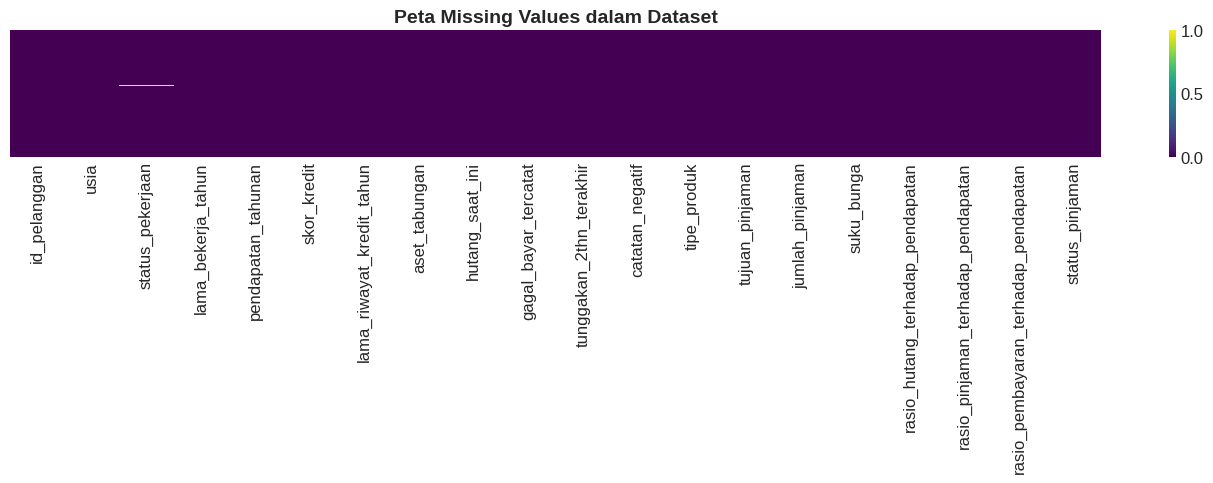

In [5]:
# ============================================
# 3.1 Cek Missing Values
# ============================================
print("🔍 Pengecekan Missing Values:")
print("=" * 50)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0]

if len(missing_df) > 0:
    print(missing_df)
    print(f"\nTotal kolom dengan missing values: {len(missing_df)}")
else:
    print("✅ Tidak ada missing values dalam dataset!")

# Visualisasi missing values
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Peta Missing Values dalam Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# ============================================
# 3.2 Handling Missing Values
# ============================================
# KEPUTUSAN DESAIN: TIDAK ada imputasi global untuk modeling.
# - 'usia' (numerik)         → dibiarkan NaN, diimputasi per-fold di Step 9 & 10
# - 'status_pekerjaan' (kat) → dibiarkan NaN, diimputasi per-fold di Step 9 & 10
# Dengan ini, data validasi TIDAK pernah memengaruhi nilai imputasi (zero leakage).
# One-Hot Encoding juga dilakukan per-fold (Step 9 & 10) bukan secara global.
print("🔧 Penanganan Missing Values:")
print("=" * 50)
print(f"Jumlah baris: {len(df):,}")

missing_cols = df.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]
if len(missing_cols) > 0:
    for col, n in missing_cols.items():
        dtype = df[col].dtype
        strategy = "median per-fold (Step 9 & 10)" if dtype != 'object' else "modus per-fold (Step 9 & 10)"
        print(f"  - '{col}': {n} missing → DIBIARKAN NaN → diimputasi {strategy}")
else:
    print("  ✅ Tidak ada missing values dalam dataset!")

print(f"\nTotal missing tersisa: {df.isnull().sum().sum()}")
print("✅ Semua missing values akan dikelola per-fold (zero leakage)!")


🔧 Penanganan Missing Values:
Jumlah baris: 50,000
  - 'usia': 142 missing → DIBIARKAN NaN → diimputasi median per-fold (Step 9 & 10)
  - 'status_pekerjaan': 158 missing → DIBIARKAN NaN → diimputasi modus per-fold (Step 9 & 10)

Total missing tersisa: 300
✅ Semua missing values akan dikelola per-fold (zero leakage)!


## 4. Exploratory Data Analysis (EDA)

Visualisasi dan analisis dilakukan **sebelum encoding** agar label kategorikal asli tetap terbaca dan interpretasi lebih mudah dipahami. Tahap EDA meliputi:
- Distribusi variabel target
- Distribusi fitur numerik dan kategorikal
- Korelasi antar fitur numerik
- Statistik deskriptif per kelas


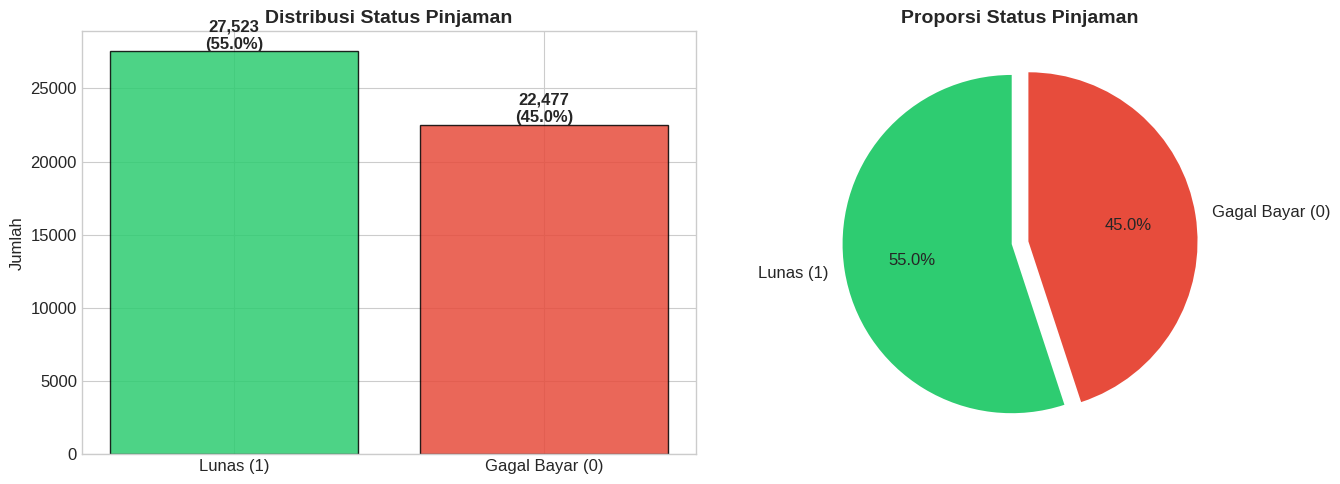


📊 Distribusi Target:
   Lunas (1)      : 27,523 (55.05%)
   Gagal Bayar (0): 22,477 (44.95%)


In [7]:
# ============================================
# 4.1 Distribusi Variabel Target
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
target_counts = df['status_pinjaman'].value_counts()
labels = ['Lunas (1)', 'Gagal Bayar (0)']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, [target_counts[1], target_counts[0]], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Distribusi Status Pinjaman', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate([target_counts[1], target_counts[0]]):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie([target_counts[1], target_counts[0]], labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05),
            textprops={'fontsize': 12})
axes[1].set_title('Proporsi Status Pinjaman', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Distribusi Target:")
print(f"   Lunas (1)      : {target_counts[1]:,} ({target_counts[1]/len(df)*100:.2f}%)")
print(f"   Gagal Bayar (0): {target_counts[0]:,} ({target_counts[0]/len(df)*100:.2f}%)")


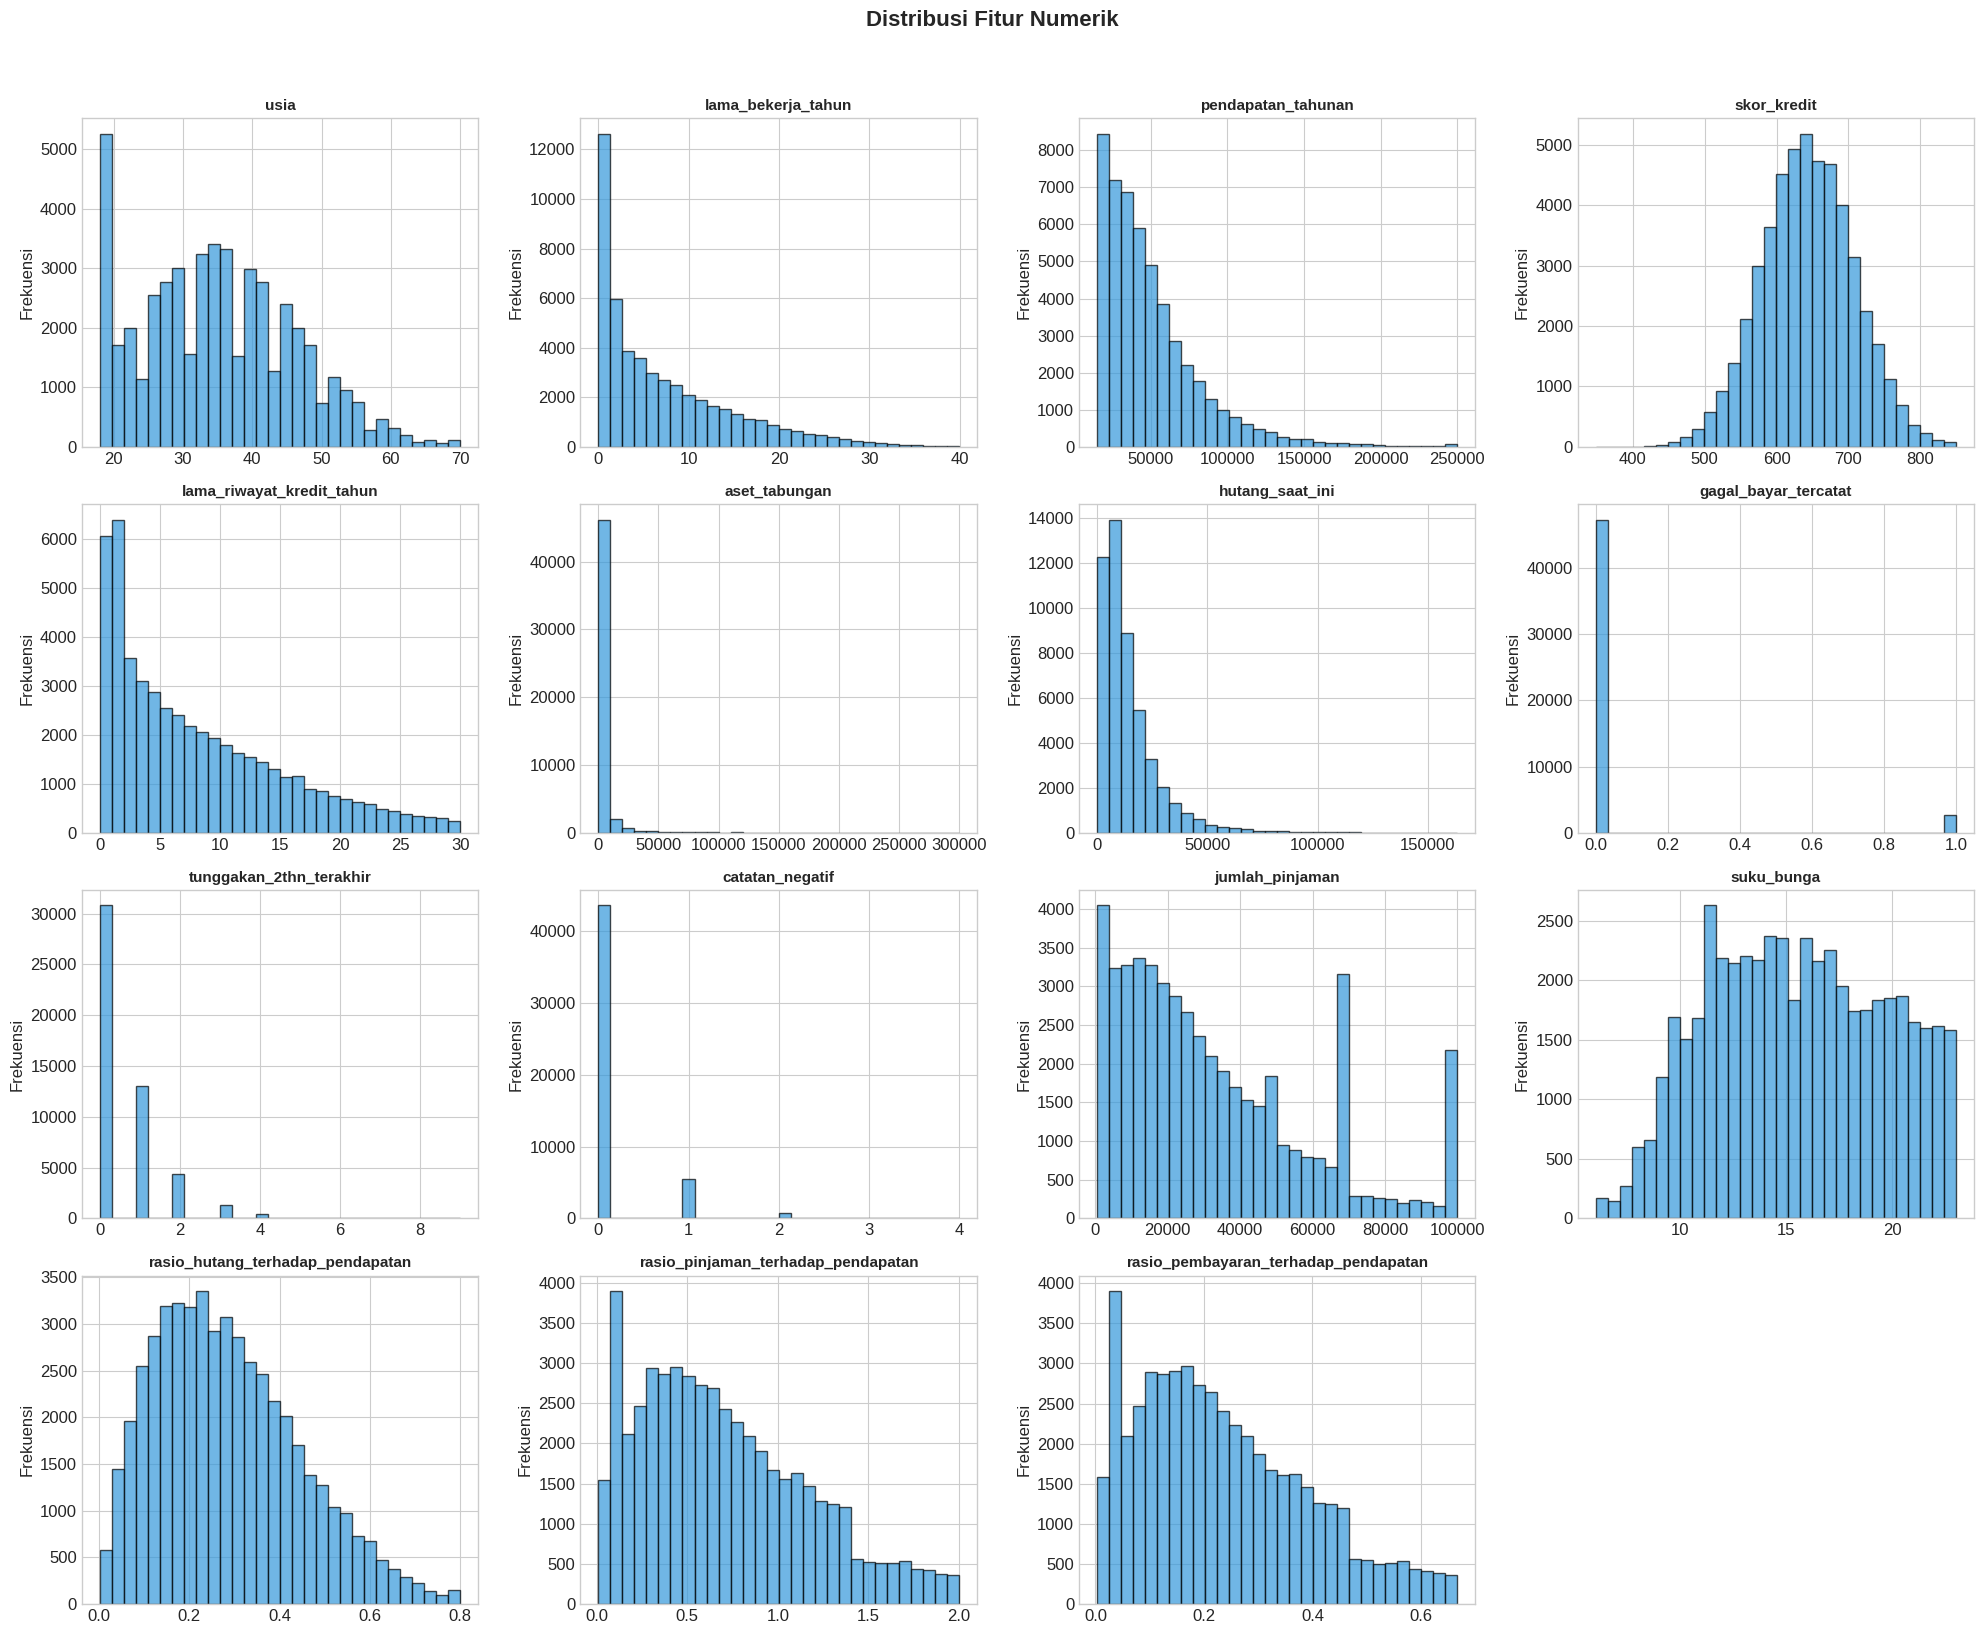

In [8]:
# ============================================
# 4.2 Distribusi Fitur Numerik (Histogram)
# ============================================
num_cols = df.select_dtypes(include=[np.number]).columns.drop('status_pinjaman').tolist()

n_cols_plot = 4
n_rows_plot = int(np.ceil(len(num_cols) / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(20, n_rows_plot * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[col].hist(ax=axes[i], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Frekuensi')

# Hapus axes kosong
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [9]:
# ============================================
# 4.2b Distribusi Fitur Kategorikal (Bar Chart)
# ============================================
# cat_cols_eda = df.select_dtypes(include='object').columns.tolist()

# if cat_cols_eda:
#     n_cat = len(cat_cols_eda)
#     fig, axes = plt.subplots(1, n_cat, figsize=(6 * n_cat, 5))
#     if n_cat == 1:
#         axes = [axes]

#     for i, col in enumerate(cat_cols_eda):
#         vc = df[col].value_counts()
#         axes[i].bar(vc.index, vc.values, color='#9b59b6', edgecolor='black', alpha=0.85)
#         axes[i].set_title(col, fontsize=11, fontweight='bold')
#         axes[i].set_ylabel('Frekuensi')
#         axes[i].tick_params(axis='x', rotation=30)
#         for j, v in enumerate(vc.values):
#             axes[i].text(j, v + 50, f'{v:,}', ha='center', fontsize=9)

#     plt.suptitle('Distribusi Fitur Kategorikal', fontsize=16, fontweight='bold', y=1.02)
#     plt.tight_layout()
#     plt.show()
# else:
#     print("Tidak ada fitur kategorikal dalam dataset.")


In [10]:
# ============================================
# 4.3 Boxplot Fitur Numerik berdasarkan Kelas Target
# ============================================
# fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(20, n_rows_plot * 4))
# axes = axes.flatten()

# for i, col in enumerate(num_cols):
#     sns.boxplot(x='status_pinjaman', y=col, data=df, ax=axes[i],
#                 palette=['#e74c3c', '#2ecc71'], order=[0, 1])
#     axes[i].set_title(col, fontsize=11, fontweight='bold')
#     axes[i].set_xticks([0, 1])
#     axes[i].set_xticklabels(['Gagal Bayar (0)', 'Lunas (1)'])

# for j in range(len(num_cols), len(axes)):
#     fig.delaxes(axes[j])

# plt.suptitle('Boxplot Fitur Numerik berdasarkan Status Pinjaman', fontsize=16, fontweight='bold', y=1.02)
# plt.tight_layout()
# plt.show()


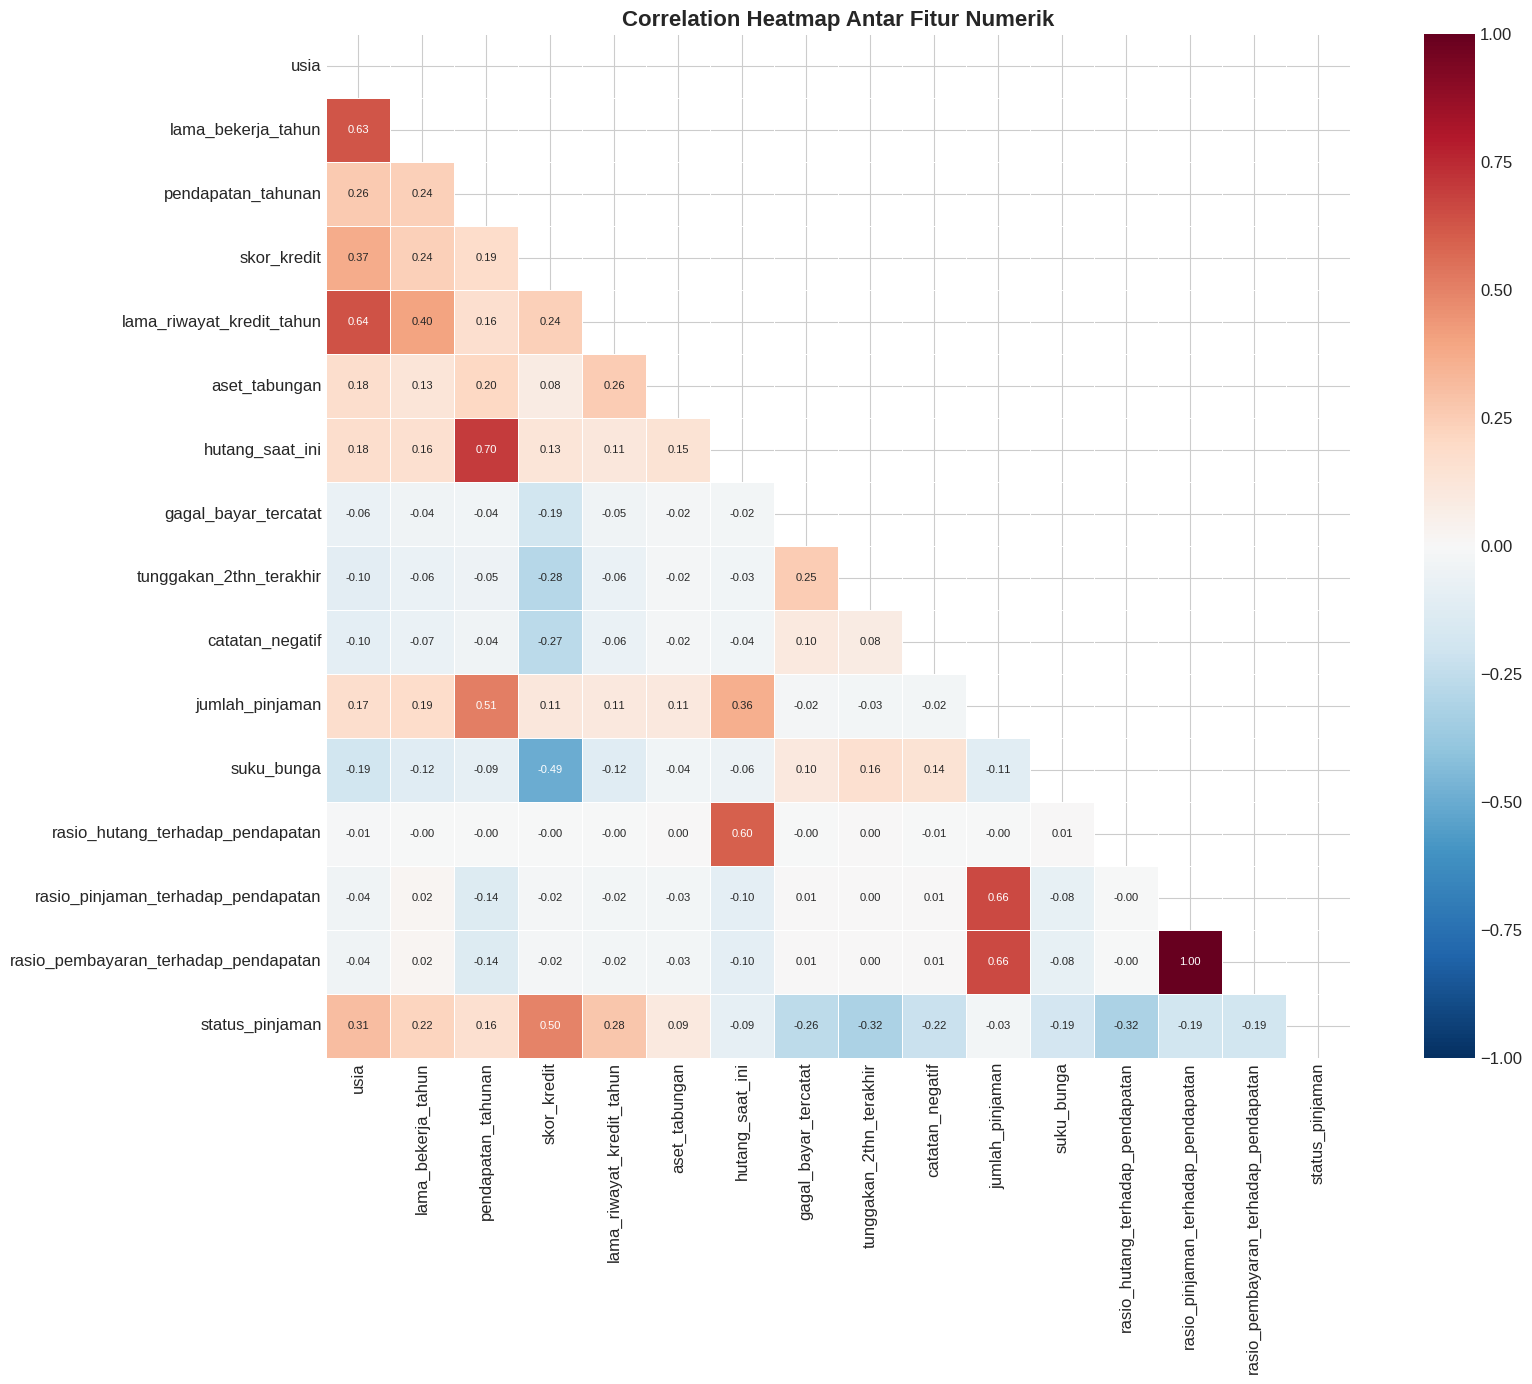


📊 Korelasi Fitur Numerik dengan Status Pinjaman (Target):
  skor_kredit                                   : +0.4963 (↑ Positif)
  usia                                          : +0.3117 (↑ Positif)
  lama_riwayat_kredit_tahun                     : +0.2771 (↑ Positif)
  lama_bekerja_tahun                            : +0.2189 (↑ Positif)
  pendapatan_tahunan                            : +0.1585 (↑ Positif)
  aset_tabungan                                 : +0.0948 (↑ Positif)
  jumlah_pinjaman                               : -0.0260 (↓ Negatif)
  hutang_saat_ini                               : -0.0885 (↓ Negatif)
  suku_bunga                                    : -0.1852 (↓ Negatif)
  rasio_pinjaman_terhadap_pendapatan            : -0.1933 (↓ Negatif)
  rasio_pembayaran_terhadap_pendapatan          : -0.1933 (↓ Negatif)
  catatan_negatif                               : -0.2247 (↓ Negatif)
  gagal_bayar_tercatat                          : -0.2630 (↓ Negatif)
  rasio_hutang_terhadap_pendapa

In [11]:
# ============================================
# 4.4 Correlation Heatmap
# ============================================
fig, ax = plt.subplots(figsize=(18, 14))

# Gunakan hanya kolom numerik agar kompatibel dengan pandas versi baru
corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)

ax.set_title('Correlation Heatmap Antar Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi dengan target
print("\n📊 Korelasi Fitur Numerik dengan Status Pinjaman (Target):")
print("=" * 50)
corr_target = corr_matrix['status_pinjaman'].drop('status_pinjaman').sort_values(ascending=False)
for feat, corr_val in corr_target.items():
    direction = "↑ Positif" if corr_val > 0 else "↓ Negatif"
    print(f"  {feat:45s} : {corr_val:+.4f} ({direction})")


In [12]:
# ============================================
# 4.5 Statistik Deskriptif per Kelas Target
# ============================================
print("📊 Statistik Deskriptif per Kelas Target:")
print("=" * 60)

print("\n🔴 Kelas 0 - Gagal Bayar:")
print(df[df['status_pinjaman'] == 0].describe().round(2))

print("\n🟢 Kelas 1 - Lunas:")
print(df[df['status_pinjaman'] == 1].describe().round(2))


📊 Statistik Deskriptif per Kelas Target:

🔴 Kelas 0 - Gagal Bayar:
           usia  lama_bekerja_tahun  pendapatan_tahunan  skor_kredit  \
count  22403.00            22477.00            22477.00     22477.00   
mean      31.13                5.61            44341.07       608.06   
std       10.33                6.59            27911.93        57.75   
min       18.00                0.00            15000.00       348.00   
25%       22.00                1.00            24674.00       571.00   
50%       30.00                2.90            37127.00       603.00   
75%       38.00                8.40            55614.00       643.00   
max       70.00               39.70           250000.00       850.00   

       lama_riwayat_kredit_tahun  aset_tabungan  hutang_saat_ini  \
count                   22477.00       22477.00         22477.00   
mean                        5.96        2207.67         15587.32   
std                         6.26        9678.78         14675.97   
min         

## 5. Cek Keseimbangan Kelas (Class Imbalance Check)

Pengecekan distribusi kelas pada variabel target sangat penting dilakukan **sebelum** membangun model. Data yang tidak seimbang dapat menyebabkan model bias terhadap kelas mayoritas.

**Kriteria:**
- Rasio > 1:1.5 → dianggap **imbalanced** dan perlu penanganan
- Rasio ≤ 1:1.5 → dianggap **relatif seimbang**

⚖️  ANALISIS KESEIMBANGAN KELAS

📊 Distribusi Kelas:
   Kelas 0 (Gagal Bayar) : 22,477 sampel (44.95%)
   Kelas 1 (Lunas)       : 27,523 sampel (55.05%)

   Kelas Mayoritas       : Lunas (1)
   Kelas Minoritas       : Gagal Bayar (0)

   Imbalance Ratio       : 1 : 1.22


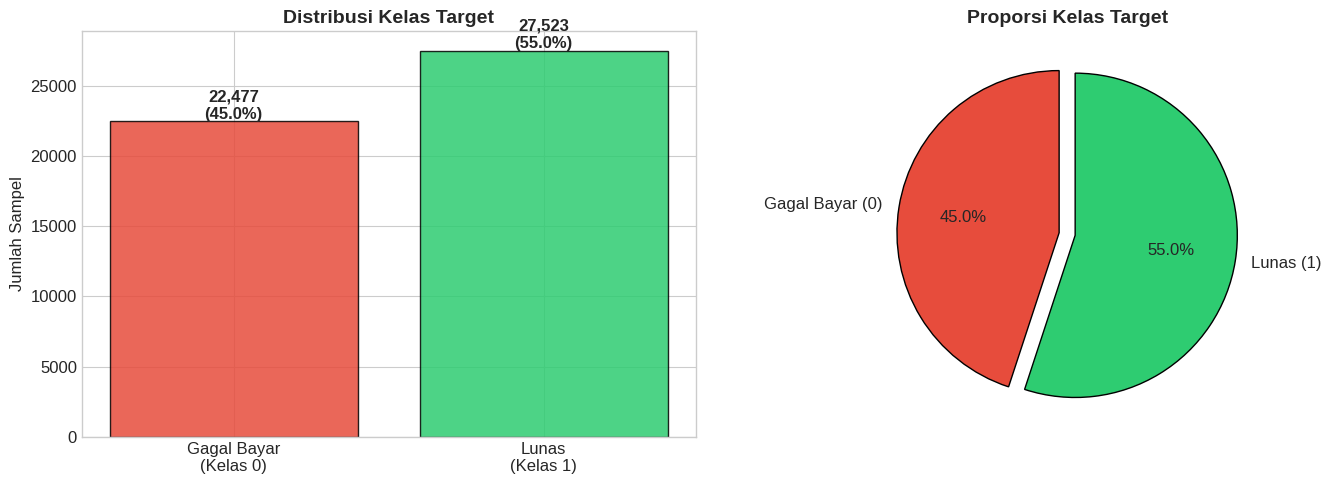


✅ KEPUTUSAN: Data RELATIF SEIMBANG (rasio 1:1.22)
   → SMOTE tetap diterapkan mengikuti jurnal referensi
     untuk memperkuat batas keputusan kelas minoritas
     pada setiap fold training.


In [13]:
# ============================================
# 5. Cek Keseimbangan Kelas
# ============================================
print("⚖️  ANALISIS KESEIMBANGAN KELAS")
print("=" * 60)

target_counts = df['status_pinjaman'].value_counts()
total = len(df)

kelas_0 = target_counts[0]  # Gagal Bayar
kelas_1 = target_counts[1]  # Lunas

majority = max(kelas_0, kelas_1)
minority = min(kelas_0, kelas_1)
imbalance_ratio = majority / minority

print(f"\n📊 Distribusi Kelas:")
print(f"   Kelas 0 (Gagal Bayar) : {kelas_0:,} sampel ({kelas_0/total*100:.2f}%)")
print(f"   Kelas 1 (Lunas)       : {kelas_1:,} sampel ({kelas_1/total*100:.2f}%)")
print(f"\n   Kelas Mayoritas       : {'Lunas (1)' if kelas_1 > kelas_0 else 'Gagal Bayar (0)'}")
print(f"   Kelas Minoritas       : {'Gagal Bayar (0)' if kelas_1 > kelas_0 else 'Lunas (1)'}")
print(f"\n   Imbalance Ratio       : 1 : {imbalance_ratio:.2f}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
bars = axes[0].bar(['Gagal Bayar\n(Kelas 0)', 'Lunas\n(Kelas 1)'],
                    [kelas_0, kelas_1],
                    color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
axes[0].set_title('Distribusi Kelas Target', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for bar, val in zip(bars, [kelas_0, kelas_1]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}\n({val/total*100:.1f}%)', ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie([kelas_0, kelas_1],
            labels=['Gagal Bayar (0)', 'Lunas (1)'],
            colors=['#e74c3c', '#2ecc71'],
            autopct='%1.1f%%', startangle=90,
            explode=(0.05, 0.05), textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'black', 'linewidth': 1})
axes[1].set_title('Proporsi Kelas Target', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Keputusan penggunaan SMOTE
print("\n" + "=" * 60)
if imbalance_ratio > 1.5:
    print(f"⚠️  KEPUTUSAN: Data TIDAK SEIMBANG (rasio 1:{imbalance_ratio:.2f})")
    print("   → SMOTE diterapkan pada data training setiap fold")
else:
    print(f"✅ KEPUTUSAN: Data RELATIF SEIMBANG (rasio 1:{imbalance_ratio:.2f})")
    print("   → SMOTE tetap diterapkan mengikuti jurnal referensi")
    print("     untuk memperkuat batas keputusan kelas minoritas")
    print("     pada setiap fold training.")
print("=" * 60)

## 6. Preprocessing Lanjutan: Drop Kolom dan One-Hot Encoding

Setelah EDA dan pengecekan keseimbangan kelas, lakukan preprocessing lanjutan:
- Drop kolom tidak relevan (`id_pelanggan`) dan kolom yang mengandung **data leakage** (`gagal_bayar_tercatat`)
- **One-Hot Encoding** untuk mengubah variabel kategorikal menjadi representasi numerik tanpa urutan


In [5]:
# ============================================
# 6. Drop Kolom Tidak Relevan & Identifikasi Kolom Kategorikal
# ============================================
# One-Hot Encoding TIDAK dilakukan di sini secara global.
# OHE dilakukan per-fold di Step 9 & 10 menggunakan OneHotEncoder
# yang di-fit hanya pada data training fold → zero leakage.

df.drop('id_pelanggan', axis=1, inplace=True)
print("🗑️  Kolom 'id_pelanggan' di-drop (bukan fitur prediktif)")

df.drop('gagal_bayar_tercatat', axis=1, inplace=True)
print("🗑️  Kolom 'gagal_bayar_tercatat' di-drop (DATA LEAKAGE: 100% prediktif terhadap target)\n")

# Identifikasi kolom kategorikal — untuk referensi Step 9 & 10
cat_cols_global = df.select_dtypes(include='object').columns.tolist()
print(f"📋 Kolom kategorikal yang akan di-OHE per-fold: {cat_cols_global}")
print(f"   → OneHotEncoder.fit() hanya pada X_train_fold setiap iterasi CV")
print(f"\nShape dataset: {df.shape}")
print(f"Tipe data:\n{df.dtypes}")
print("\n✅ Step 6 selesai. OHE akan dilakukan per-fold di Step 9 & 10.")


🗑️  Kolom 'id_pelanggan' di-drop (bukan fitur prediktif)
🗑️  Kolom 'gagal_bayar_tercatat' di-drop (DATA LEAKAGE: 100% prediktif terhadap target)

📋 Kolom kategorikal yang akan di-OHE per-fold: ['status_pekerjaan', 'tipe_produk', 'tujuan_pinjaman']
   → OneHotEncoder.fit() hanya pada X_train_fold setiap iterasi CV

Shape dataset: (50000, 18)
Tipe data:
usia                                    float64
status_pekerjaan                         object
lama_bekerja_tahun                      float64
pendapatan_tahunan                        int64
skor_kredit                               int64
lama_riwayat_kredit_tahun               float64
aset_tabungan                             int64
hutang_saat_ini                           int64
tunggakan_2thn_terakhir                   int64
catatan_negatif                           int64
tipe_produk                              object
tujuan_pinjaman                          object
jumlah_pinjaman                           int64
suku_bunga            

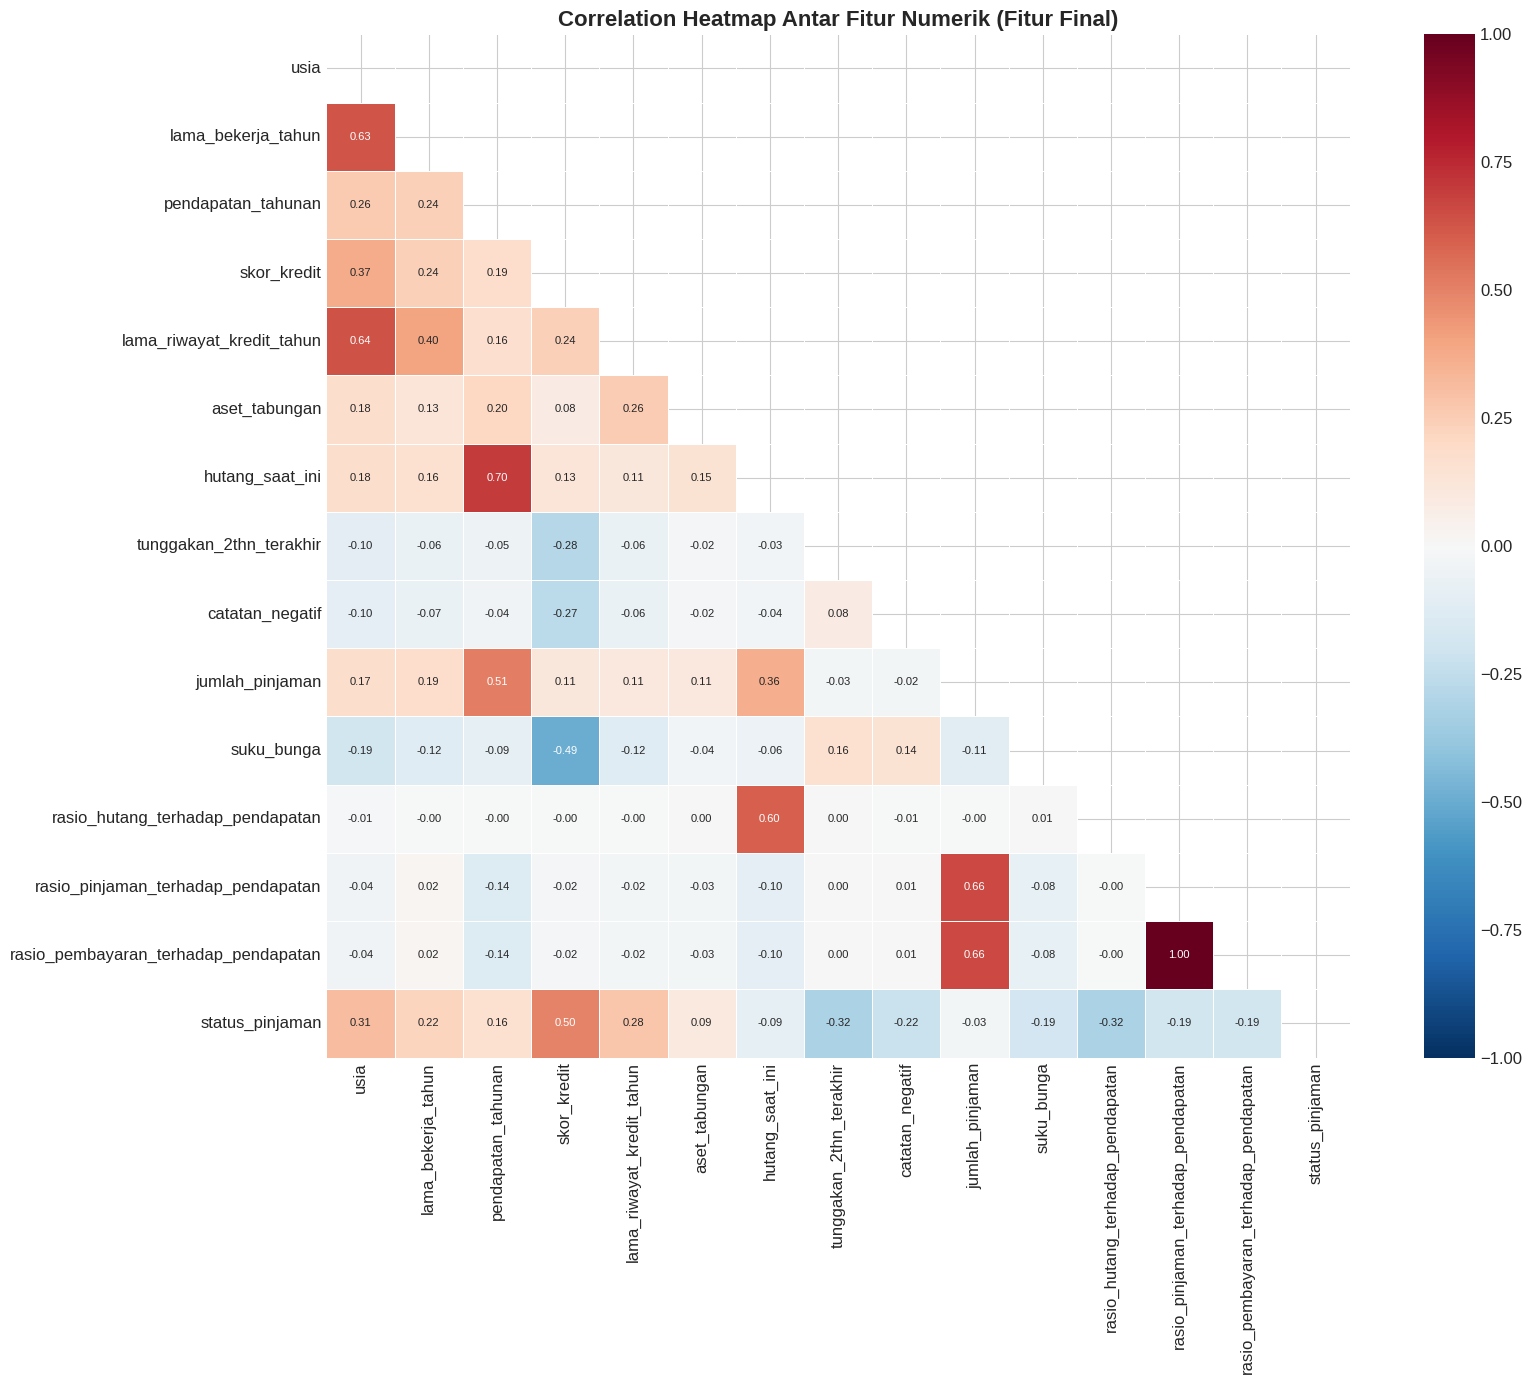

In [6]:
# ============================================
# Correlation Heatmap SETELAH drop kolom
# (untuk Figure 4.2 di Bab IV)
# ============================================
fig, ax = plt.subplots(figsize=(18, 14))

corr_matrix_final = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix_final, dtype=bool))

sns.heatmap(corr_matrix_final, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)

ax.set_title('Correlation Heatmap Antar Fitur Numerik (Fitur Final)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Penanganan Ketidakseimbangan Kelas dengan SMOTE

**SMOTE (Synthetic Minority Over-sampling Technique)** menghasilkan sampel sintetis untuk kelas minoritas berdasarkan interpolasi antara sampel-sampel yang berdekatan (k-nearest neighbors).

> ⚠️ **Penting (No Leakage):** SMOTE **tidak boleh** diterapkan ke seluruh dataset sebelum cross validation.
> SMOTE harus dilakukan **hanya pada data training di tiap fold**, sementara data validation/test tetap data asli.


📊 Distribusi Kelas TRAIN fold (sebelum SMOTE):
   Kelas 0 (Gagal Bayar): 20,230
   Kelas 1 (Lunas)      : 24,770

📊 Distribusi Kelas TRAIN fold (sesudah SMOTE):
   Kelas 0 (Gagal Bayar): 24,770
   Kelas 1 (Lunas)      : 24,770

📊 Distribusi Kelas VALIDATION fold (tetap asli, tanpa SMOTE):
   Kelas 0 (Gagal Bayar): 2,247
   Kelas 1 (Lunas)      : 2,753


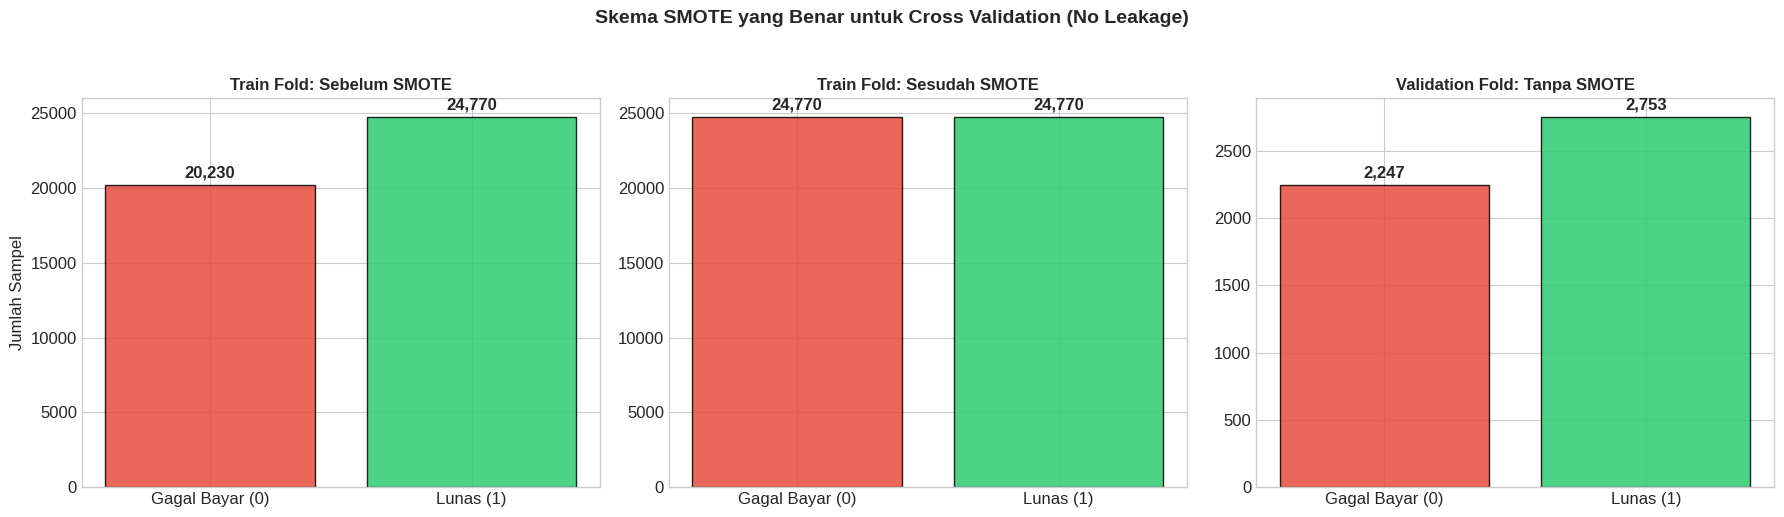

In [7]:
# ============================================
# 7. Demonstrasi SMOTE TANPA Data Leakage
# ============================================
# Demonstrasi ini menunjukkan pola yang benar:
# 1) Split fold terlebih dahulu
# 2) Imputasi + OHE hanya pada data TRAIN fold (no leakage)
# 3) SMOTE hanya pada data TRAIN fold
# 4) Data VALIDATION fold tetap asli

X_demo = df.drop('status_pinjaman', axis=1)
y_demo = df['status_pinjaman']

num_cols_demo = X_demo.select_dtypes(exclude='object').columns.tolist()
cat_cols_demo = X_demo.select_dtypes(include='object').columns.tolist()

skf_demo = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
train_idx_demo, val_idx_demo = next(skf_demo.split(X_demo, y_demo))

X_train_demo = X_demo.iloc[train_idx_demo].copy()
X_val_demo   = X_demo.iloc[val_idx_demo].copy()
y_train_demo = y_demo.iloc[train_idx_demo]
y_val_demo   = y_demo.iloc[val_idx_demo]

# ── Imputasi per-fold (no leakage) ──
for col in num_cols_demo:
    if X_train_demo[col].isnull().any():
        med = X_train_demo[col].median()
        X_train_demo[col] = X_train_demo[col].fillna(med)
        X_val_demo[col]   = X_val_demo[col].fillna(med)
for col in cat_cols_demo:
    if X_train_demo[col].isnull().any():
        mod = X_train_demo[col].mode()[0]
        X_train_demo[col] = X_train_demo[col].fillna(mod)
        X_val_demo[col]   = X_val_demo[col].fillna(mod)

# ── OHE per-fold (fit hanya pada train) ──
ohe_demo = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
train_ohe = ohe_demo.fit_transform(X_train_demo[cat_cols_demo])
val_ohe   = ohe_demo.transform(X_val_demo[cat_cols_demo])
ohe_names_demo = ohe_demo.get_feature_names_out(cat_cols_demo).tolist()

X_train_demo_enc = pd.concat([
    X_train_demo[num_cols_demo].reset_index(drop=True),
    pd.DataFrame(train_ohe, columns=ohe_names_demo)
], axis=1)
X_val_demo_enc = pd.concat([
    X_val_demo[num_cols_demo].reset_index(drop=True),
    pd.DataFrame(val_ohe, columns=ohe_names_demo)
], axis=1)

# ── SMOTE hanya pada train ──
smote_demo = SMOTE(random_state=42)
X_train_smote_demo, y_train_smote_demo = smote_demo.fit_resample(X_train_demo_enc, y_train_demo)

print("📊 Distribusi Kelas TRAIN fold (sebelum SMOTE):")
print(f"   Kelas 0 (Gagal Bayar): {(y_train_demo == 0).sum():,}")
print(f"   Kelas 1 (Lunas)      : {(y_train_demo == 1).sum():,}")

print("\n📊 Distribusi Kelas TRAIN fold (sesudah SMOTE):")
print(f"   Kelas 0 (Gagal Bayar): {(y_train_smote_demo == 0).sum():,}")
print(f"   Kelas 1 (Lunas)      : {(y_train_smote_demo == 1).sum():,}")

print("\n📊 Distribusi Kelas VALIDATION fold (tetap asli, tanpa SMOTE):")
print(f"   Kelas 0 (Gagal Bayar): {(y_val_demo == 0).sum():,}")
print(f"   Kelas 1 (Lunas)      : {(y_val_demo == 1).sum():,}")

# Visualisasi ringkas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

train_before = [(y_train_demo == 0).sum(), (y_train_demo == 1).sum()]
train_after  = [(y_train_smote_demo == 0).sum(), (y_train_smote_demo == 1).sum()]
val_orig     = [(y_val_demo == 0).sum(), (y_val_demo == 1).sum()]

axes[0].bar(['Gagal Bayar (0)', 'Lunas (1)'], train_before,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
axes[0].set_title('Train Fold: Sebelum SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')

axes[1].bar(['Gagal Bayar (0)', 'Lunas (1)'], train_after,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
axes[1].set_title('Train Fold: Sesudah SMOTE', fontsize=12, fontweight='bold')

axes[2].bar(['Gagal Bayar (0)', 'Lunas (1)'], val_orig,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
axes[2].set_title('Validation Fold: Tanpa SMOTE', fontsize=12, fontweight='bold')

for ax, vals in zip(axes, [train_before, train_after, val_orig]):
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals) * 0.02, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Skema SMOTE yang Benar untuk Cross Validation (No Leakage)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Bersihkan memory
del (X_demo, y_demo, X_train_demo, X_val_demo, y_train_demo, y_val_demo,
     X_train_demo_enc, X_val_demo_enc, X_train_smote_demo, y_train_smote_demo,
     ohe_demo, smote_demo, skf_demo, train_idx_demo, val_idx_demo)

## 8. Feature Selection dan Splitting Data

Pisahkan fitur (X) dan variabel target (y). Siapkan data untuk proses **Stratified K-Fold Cross Validation**.

**Mengapa Stratified K-Fold?**
- Mempertahankan proporsi kelas di setiap fold
- Lebih representatif dibandingkan K-Fold biasa untuk data imbalanced
- Menghasilkan estimasi performa yang lebih reliable


In [16]:
# ============================================
# 8. Splitting Data dan Persiapan Cross Validation
# ============================================

X = df.drop('status_pinjaman', axis=1)
y = df['status_pinjaman']

num_cols = X.select_dtypes(exclude='object').columns.tolist()
cat_cols  = X.select_dtypes(include='object').columns.tolist()

print("📋 Kolom numerik  :", num_cols)
print("📋 Kolom kategorikal:", cat_cols)
print(f"\nTotal sampel: {len(X):,}")
print(f"Shape X (pre-OHE): {X.shape}")
print(f"Shape y: {y.shape}")
print("\n⚠️  feature_names (post-OHE) akan diset setelah fold pertama selesai di Step 9.")
print(f"\n✅ Tidak menggunakan StandardScaler (tree-based model tidak sensitif skala)")

N_SPLITS = 10
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
print(f"\n✅ Stratified {N_SPLITS}-Fold Cross Validation siap digunakan")

print(f"\n📊 Verifikasi Proporsi Kelas di Setiap Fold:")
print("-" * 50)
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    y_train_fold = y.iloc[train_idx]
    y_val_fold   = y.iloc[val_idx]
    tr = y_train_fold.value_counts(normalize=True)
    vl = y_val_fold.value_counts(normalize=True)
    print(f"  Fold {fold:2d} | Train: 0={tr[0]:.3f}, 1={tr[1]:.3f} | "
          f"Val: 0={vl[0]:.3f}, 1={vl[1]:.3f} | "
          f"Train={len(train_idx):,}, Val={len(val_idx):,}")


📋 Kolom numerik  : ['usia', 'lama_bekerja_tahun', 'pendapatan_tahunan', 'skor_kredit', 'lama_riwayat_kredit_tahun', 'aset_tabungan', 'hutang_saat_ini', 'tunggakan_2thn_terakhir', 'catatan_negatif', 'jumlah_pinjaman', 'suku_bunga', 'rasio_hutang_terhadap_pendapatan', 'rasio_pinjaman_terhadap_pendapatan', 'rasio_pembayaran_terhadap_pendapatan']
📋 Kolom kategorikal: ['status_pekerjaan', 'tipe_produk', 'tujuan_pinjaman']

Total sampel: 50,000
Shape X (pre-OHE): (50000, 17)
Shape y: (50000,)

⚠️  feature_names (post-OHE) akan diset setelah fold pertama selesai di Step 9.

✅ Tidak menggunakan StandardScaler (tree-based model tidak sensitif skala)

✅ Stratified 10-Fold Cross Validation siap digunakan

📊 Verifikasi Proporsi Kelas di Setiap Fold:
--------------------------------------------------
  Fold  1 | Train: 0=0.450, 1=0.550 | Val: 0=0.449, 1=0.551 | Train=45,000, Val=5,000
  Fold  2 | Train: 0=0.450, 1=0.550 | Val: 0=0.449, 1=0.551 | Train=45,000, Val=5,000
  Fold  3 | Train: 0=0.450, 1

## 9. Membangun Model Random Forest dengan Stratified K-Fold Cross Validation

Random Forest adalah algoritma ensemble berbasis **bagging** yang membangun banyak pohon keputusan secara paralel dan menggabungkan prediksinya melalui voting.

**Hyperparameter tuning:** dilakukan dengan **Nested Cross Validation** — GridSearchCV dijalankan **di dalam setiap fold training** sehingga data validasi tidak pernah terlihat saat tuning. Pendekatan ini menghindari *hyperparameter leakage* yang terjadi jika GridSearchCV dijalankan pada seluruh dataset sebelum loop evaluasi.

Pada setiap fold evaluasi:
1. Data training fold di-tuning dengan GridSearchCV (inner 5-fold)
2. Hyperparameter terbaik digunakan untuk melatih model pada data training fold yang di-SMOTE
3. Evaluasi pada data validasi fold (tanpa SMOTE)
4. Prediksi dikumpulkan sebagai **Out-of-Fold (OOF)** untuk confusion matrix & ROC yang representatif


In [17]:
# ============================================
# 9. Model Random Forest + Nested Stratified K-Fold CV
# ============================================
print("🌲 TRAINING RANDOM FOREST dengan Nested Stratified K-Fold CV")
print("=" * 70)
print("ℹ️  Setiap fold: imputasi → OHE → SMOTE → nested GridSearchCV → evaluasi")
print()

rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 15],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}
# 2×2×2×2 = 16 kombinasi × 3 inner fold × 10 outer fold = 480 model

rf_inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1_score': [], 'f2_score': [], 'auc': []}
rf_oof_y_true = []; rf_oof_y_pred = []; rf_oof_y_prob = []
rf_best_params_per_fold = []; rf_all_importances = []
feature_names = None  # diset pada fold pertama

print(f"{'='*70}")
print(f"{'Fold':<6} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'F2-Score':>10} {'AUC':>10}")
print(f"{'='*70}")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_raw = X.iloc[train_idx].copy()
    X_val_raw   = X.iloc[val_idx].copy()
    y_train_fold = y.iloc[train_idx]
    y_val_fold   = y.iloc[val_idx]

    # ─── 1. Imputasi per-fold (no leakage) ───
    # Numerik: median dari train fold
    for col in num_cols:
        if X_train_raw[col].isnull().any():
            med = X_train_raw[col].median()
            X_train_raw[col] = X_train_raw[col].fillna(med)
            X_val_raw[col]   = X_val_raw[col].fillna(med)
    # Kategorikal: modus dari train fold
    for col in cat_cols:
        if X_train_raw[col].isnull().any():
            mod = X_train_raw[col].mode()[0]
            X_train_raw[col] = X_train_raw[col].fillna(mod)
            X_val_raw[col]   = X_val_raw[col].fillna(mod)

    # ─── 2. One-Hot Encoding per-fold (no leakage) ───
    ohe_fold = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_train_ohe = ohe_fold.fit_transform(X_train_raw[cat_cols])   # fit HANYA pada train
    X_val_ohe   = ohe_fold.transform(X_val_raw[cat_cols])          # transform val pakai vocab train
    ohe_col_names = ohe_fold.get_feature_names_out(cat_cols).tolist()

    X_train_fold = pd.concat([
        X_train_raw[num_cols].reset_index(drop=True),
        pd.DataFrame(X_train_ohe, columns=ohe_col_names)
    ], axis=1)
    X_val_fold = pd.concat([
        X_val_raw[num_cols].reset_index(drop=True),
        pd.DataFrame(X_val_ohe, columns=ohe_col_names)
    ], axis=1)

    # Simpan feature_names dari fold pertama (konsisten semua fold)
    if feature_names is None:
        feature_names = num_cols + ohe_col_names

    # ─── 3. Nested GridSearchCV (fit HANYA pada X_train_fold) ───
    rf_pipeline_inner = Pipeline(steps=[
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(random_state=42, n_jobs=1))
    ])
    rf_grid = GridSearchCV(rf_pipeline_inner, rf_param_grid, scoring='f1', cv=rf_inner_cv, n_jobs=-1)
    rf_grid.fit(X_train_fold, y_train_fold)

    best_p = {k.replace('model__', ''): v for k, v in rf_grid.best_params_.items()}
    rf_best_params_per_fold.append(best_p)

    # ─── 4. SMOTE + training ───
    smote_fold = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote_fold.fit_resample(X_train_fold, y_train_fold)

    rf_model = RandomForestClassifier(**best_p, random_state=42, n_jobs=-1)
    rf_model.fit(X_train_smote, y_train_smote)

    # ─── 5. Prediksi & metrik ───
    y_pred = rf_model.predict(X_val_fold)
    y_prob = rf_model.predict_proba(X_val_fold)[:, 1]

    acc  = accuracy_score(y_val_fold, y_pred)
    prec = precision_score(y_val_fold, y_pred)
    rec  = recall_score(y_val_fold, y_pred)
    f1   = f1_score(y_val_fold, y_pred)
    f2   = fbeta_score(y_val_fold, y_pred, beta=2, zero_division=0)
    auc  = roc_auc_score(y_val_fold, y_prob)

    rf_metrics['accuracy'].append(acc); rf_metrics['precision'].append(prec)
    rf_metrics['recall'].append(rec);   rf_metrics['f1_score'].append(f1)
    rf_metrics['f2_score'].append(f2);  rf_metrics['auc'].append(auc)

    rf_oof_y_true.extend(y_val_fold.tolist())
    rf_oof_y_pred.extend(y_pred.tolist())
    rf_oof_y_prob.extend(y_prob.tolist())
    rf_all_importances.append(rf_model.feature_importances_)

    print(f"  {fold:<4} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {f2:>10.4f} {auc:>10.4f}")

print(f"{'='*70}")
print(f"  {'Mean':<4} {np.mean(rf_metrics['accuracy']):>10.4f} {np.mean(rf_metrics['precision']):>10.4f} "
      f"{np.mean(rf_metrics['recall']):>10.4f} {np.mean(rf_metrics['f1_score']):>10.4f} "
      f"{np.mean(rf_metrics['f2_score']):>10.4f} {np.mean(rf_metrics['auc']):>10.4f}")
print(f"  {'Std':<4} {np.std(rf_metrics['accuracy']):>10.4f} {np.std(rf_metrics['precision']):>10.4f} "
      f"{np.std(rf_metrics['recall']):>10.4f} {np.std(rf_metrics['f1_score']):>10.4f} "
      f"{np.std(rf_metrics['f2_score']):>10.4f} {np.std(rf_metrics['auc']):>10.4f}")
print(f"{'='*70}")

rf_avg_importance = np.mean(rf_all_importances, axis=0)

print("\n📋 Hyperparameter RF terpilih per fold:")
for i, p in enumerate(rf_best_params_per_fold, 1):
    print(f"   Fold {i:2d}: {p}")

rf_params_repr = {}
for key in rf_best_params_per_fold[0]:
    vals = [p[key] for p in rf_best_params_per_fold]
    rf_params_repr[key] = Counter(vals).most_common(1)[0][0]
rf_params_repr.update({'random_state': 42, 'n_jobs': -1})
print(f"\n✅ Hyperparameter representatif (modus): {rf_params_repr}")
print(f"✅ feature_names (post-OHE): {len(feature_names)} fitur")
print("\n✅ Training Random Forest selesai!")


🌲 TRAINING RANDOM FOREST dengan Nested Stratified K-Fold CV
ℹ️  Setiap fold: imputasi → OHE → SMOTE → nested GridSearchCV → evaluasi

Fold     Accuracy  Precision     Recall   F1-Score   F2-Score        AUC
  1        0.9040     0.9107     0.9154     0.9130     0.9144     0.9643
  2        0.9024     0.9090     0.9143     0.9116     0.9132     0.9666
  3        0.8936     0.8931     0.9165     0.9046     0.9117     0.9607
  4        0.9032     0.9059     0.9197     0.9127     0.9169     0.9683
  5        0.8958     0.9106     0.8990     0.9047     0.9013     0.9632
  6        0.9074     0.9157     0.9161     0.9159     0.9160     0.9680
  7        0.9060     0.9107     0.9193     0.9150     0.9176     0.9652
  8        0.9016     0.9044     0.9182     0.9113     0.9154     0.9657
  9        0.9022     0.9028     0.9215     0.9121     0.9177     0.9647
  10       0.8970     0.9039     0.9095     0.9067     0.9084     0.9619
  Mean     0.9013     0.9067     0.9149     0.9108     0.9133  

In [18]:
# Classification Report dari semua prediksi OOF (Out-of-Fold)
print("📋 Classification Report - Random Forest (Out-of-Fold, semua fold):")
print("=" * 60)
print(classification_report(rf_oof_y_true, rf_oof_y_pred,
                            target_names=['Gagal Bayar (0)', 'Lunas (1)']))
print("ℹ️  OOF = prediksi agregat dari semua 10 fold — lebih representatif dari satu fold terbaik.")


📋 Classification Report - Random Forest (Out-of-Fold, semua fold):
                 precision    recall  f1-score   support

Gagal Bayar (0)       0.89      0.88      0.89     22477
      Lunas (1)       0.91      0.91      0.91     27523

       accuracy                           0.90     50000
      macro avg       0.90      0.90      0.90     50000
   weighted avg       0.90      0.90      0.90     50000

ℹ️  OOF = prediksi agregat dari semua 10 fold — lebih representatif dari satu fold terbaik.


### 9.1 F2-Score & Estimasi Kerugian Finansial (Random Forest)

**F2-Score** (dengan Beta=2) memberikan bobot lebih pada **Recall** dibandingkan Precision. Dalam kasus kredit, **jauh lebih buruk meloloskan nasabah gagal bayar (False Negative)** daripada menolak nasabah yang sebenarnya mampu bayar (False Positive). Oleh karena itu, kita memantau F2-Score secara ketat.

Berikut adalah estimasi kerugian finansial pada fold terbaik:

In [19]:
# ─── Asumsi finansial (konsisten di seluruh notebook) ───
AVG_LOAN_AMOUNT  = 33_042          # rata-rata nilai pinjaman (Rp)
RECOVERY_RATE    = 0.30            # tingkat pemulihan aset saat gagal bayar (30%)
PROFIT_MARGIN    = 0.05            # profit margin per pinjaman yang berhasil (5%)
# FP (prediksi Lunas, nyatanya Gagal Bayar) → bank rugi (1 - RECOVERY_RATE) * loan
# FN (prediksi Gagal Bayar, nyatanya Lunas) → missed profit = PROFIT_MARGIN * loan
loss_per_fp = AVG_LOAN_AMOUNT * (1 - RECOVERY_RATE)  # Rp 23.129
cost_per_fn = AVG_LOAN_AMOUNT * PROFIT_MARGIN         # Rp 1.652
from sklearn.metrics import confusion_matrix as _cm
cm_rf_oof = _cm(rf_oof_y_true, rf_oof_y_pred)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf_oof.ravel()

total_fp_loss_rf = fp_rf * loss_per_fp
total_fn_cost_rf = fn_rf * cost_per_fn
total_cost_rf    = total_fp_loss_rf + total_fn_cost_rf

print("💸 Estimasi Kerugian Finansial - Random Forest (Out-of-Fold)")
print("-" * 65)
print(f"  Asumsi:")
print(f"    - Avg. nilai pinjaman      : Rp {AVG_LOAN_AMOUNT:,}")
print(f"    - Recovery rate            : {RECOVERY_RATE*100:.0f}% → kerugian per FP = Rp {loss_per_fp:,.0f}")
print(f"    - Profit margin            : {PROFIT_MARGIN*100:.0f}% → missed profit per FN = Rp {cost_per_fn:,.0f}")
print(f"  Hasil:")
print(f"    FP (diprediksi Lunas, nyatanya Gagal Bayar) : {fp_rf:,} kasus → Rp {total_fp_loss_rf:,.0f}")
print(f"    FN (diprediksi Gagal Bayar, nyatanya Lunas)  : {fn_rf:,} kasus → Rp {total_fn_cost_rf:,.0f}")
print(f"    TOTAL ESTIMASI KERUGIAN                      : Rp {total_cost_rf:,.0f}")


💸 Estimasi Kerugian Finansial - Random Forest (Out-of-Fold)
-----------------------------------------------------------------
  Asumsi:
    - Avg. nilai pinjaman      : Rp 33,042
    - Recovery rate            : 30% → kerugian per FP = Rp 23,129
    - Profit margin            : 5% → missed profit per FN = Rp 1,652
  Hasil:
    FP (diprediksi Lunas, nyatanya Gagal Bayar) : 2,593 kasus → Rp 59,974,534
    FN (diprediksi Gagal Bayar, nyatanya Lunas)  : 2,341 kasus → Rp 3,867,566
    TOTAL ESTIMASI KERUGIAN                      : Rp 63,842,100


## 10. Membangun Model XGBoost dengan Stratified K-Fold Cross Validation

XGBoost (Extreme Gradient Boosting) adalah algoritma ensemble berbasis **boosting** yang membangun pohon keputusan secara sekuensial, di mana setiap pohon baru berusaha memperbaiki kesalahan dari pohon sebelumnya.

**Hyperparameter tuning:** dilakukan dengan **Nested Cross Validation** — sama seperti Random Forest, GridSearchCV dijalankan **di dalam setiap fold training** untuk menghindari *hyperparameter leakage*. Prediksi dikumpulkan sebagai **Out-of-Fold (OOF)** untuk evaluasi yang lebih representatif.


In [20]:
# ============================================
# 10. Model XGBoost + Nested Stratified K-Fold CV
# ============================================
print("🚀 TRAINING XGBOOST dengan Nested Stratified K-Fold CV")
print("=" * 70)
print("ℹ️  Setiap fold: imputasi → OHE → SMOTE → nested GridSearchCV → evaluasi")
print()

xgb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [4, 6],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8]
}
# 2×2×2×2×1 = 16 kombinasi × 3 inner fold × 10 outer fold = 480 model

xgb_inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1_score': [], 'f2_score': [], 'auc': []}
xgb_oof_y_true = []; xgb_oof_y_pred = []; xgb_oof_y_prob = []
xgb_best_params_per_fold = []; xgb_all_importances = []

print(f"{'='*70}")
print(f"{'Fold':<6} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'F2-Score':>10} {'AUC':>10}")
print(f"{'='*70}")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_raw = X.iloc[train_idx].copy()
    X_val_raw   = X.iloc[val_idx].copy()
    y_train_fold = y.iloc[train_idx]
    y_val_fold   = y.iloc[val_idx]

    # ─── 1. Imputasi per-fold (no leakage) ───
    for col in num_cols:
        if X_train_raw[col].isnull().any():
            med = X_train_raw[col].median()
            X_train_raw[col] = X_train_raw[col].fillna(med)
            X_val_raw[col]   = X_val_raw[col].fillna(med)
    for col in cat_cols:
        if X_train_raw[col].isnull().any():
            mod = X_train_raw[col].mode()[0]
            X_train_raw[col] = X_train_raw[col].fillna(mod)
            X_val_raw[col]   = X_val_raw[col].fillna(mod)

    # ─── 2. One-Hot Encoding per-fold (no leakage) ───
    ohe_fold = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_train_ohe = ohe_fold.fit_transform(X_train_raw[cat_cols])
    X_val_ohe   = ohe_fold.transform(X_val_raw[cat_cols])
    ohe_col_names = ohe_fold.get_feature_names_out(cat_cols).tolist()

    X_train_fold = pd.concat([
        X_train_raw[num_cols].reset_index(drop=True),
        pd.DataFrame(X_train_ohe, columns=ohe_col_names)
    ], axis=1)
    X_val_fold = pd.concat([
        X_val_raw[num_cols].reset_index(drop=True),
        pd.DataFrame(X_val_ohe, columns=ohe_col_names)
    ], axis=1)

    # ─── 3. Nested GridSearchCV ───
    xgb_pipeline_inner = Pipeline(steps=[
        ('smote', SMOTE(random_state=42)),
        ('model', XGBClassifier(random_state=42, n_jobs=1,
                                use_label_encoder=False, eval_metric='logloss', verbosity=0))
    ])
    xgb_grid = GridSearchCV(xgb_pipeline_inner, xgb_param_grid, scoring='f1', cv=xgb_inner_cv, n_jobs=-1)
    xgb_grid.fit(X_train_fold, y_train_fold)

    best_p = {k.replace('model__', ''): v for k, v in xgb_grid.best_params_.items()}
    xgb_best_params_per_fold.append(best_p)

    # ─── 4. SMOTE + training ───
    smote_fold = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote_fold.fit_resample(X_train_fold, y_train_fold)

    xgb_model = XGBClassifier(**best_p, use_label_encoder=False, eval_metric='logloss',
                               random_state=42, n_jobs=-1, verbosity=0)
    xgb_model.fit(X_train_smote, y_train_smote, verbose=False)

    # ─── 5. Prediksi & metrik ───
    y_pred = xgb_model.predict(X_val_fold)
    y_prob = xgb_model.predict_proba(X_val_fold)[:, 1]

    acc  = accuracy_score(y_val_fold, y_pred)
    prec = precision_score(y_val_fold, y_pred)
    rec  = recall_score(y_val_fold, y_pred)
    f1   = f1_score(y_val_fold, y_pred)
    f2   = fbeta_score(y_val_fold, y_pred, beta=2, zero_division=0)
    auc  = roc_auc_score(y_val_fold, y_prob)

    xgb_metrics['accuracy'].append(acc); xgb_metrics['precision'].append(prec)
    xgb_metrics['recall'].append(rec);   xgb_metrics['f1_score'].append(f1)
    xgb_metrics['f2_score'].append(f2);  xgb_metrics['auc'].append(auc)

    xgb_oof_y_true.extend(y_val_fold.tolist())
    xgb_oof_y_pred.extend(y_pred.tolist())
    xgb_oof_y_prob.extend(y_prob.tolist())
    xgb_all_importances.append(xgb_model.feature_importances_)

    print(f"  {fold:<4} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {f2:>10.4f} {auc:>10.4f}")

print(f"{'='*70}")
print(f"  {'Mean':<4} {np.mean(xgb_metrics['accuracy']):>10.4f} {np.mean(xgb_metrics['precision']):>10.4f} "
      f"{np.mean(xgb_metrics['recall']):>10.4f} {np.mean(xgb_metrics['f1_score']):>10.4f} "
      f"{np.mean(xgb_metrics['f2_score']):>10.4f} {np.mean(xgb_metrics['auc']):>10.4f}")
print(f"  {'Std':<4} {np.std(xgb_metrics['accuracy']):>10.4f} {np.std(xgb_metrics['precision']):>10.4f} "
      f"{np.std(xgb_metrics['recall']):>10.4f} {np.std(xgb_metrics['f1_score']):>10.4f} "
      f"{np.std(xgb_metrics['f2_score']):>10.4f} {np.std(xgb_metrics['auc']):>10.4f}")
print(f"{'='*70}")

xgb_avg_importance = np.mean(xgb_all_importances, axis=0)

print("\n📋 Hyperparameter XGB terpilih per fold:")
for i, p in enumerate(xgb_best_params_per_fold, 1):
    print(f"   Fold {i:2d}: {p}")

xgb_params_repr = {}
for key in xgb_best_params_per_fold[0]:
    vals = [p[key] for p in xgb_best_params_per_fold]
    xgb_params_repr[key] = Counter(vals).most_common(1)[0][0]
xgb_params_repr.update({'use_label_encoder': False, 'eval_metric': 'logloss',
                         'random_state': 42, 'n_jobs': -1, 'verbosity': 0})
print(f"\n✅ Hyperparameter representatif (modus): {xgb_params_repr}")
print("\n✅ Training XGBoost selesai!")


🚀 TRAINING XGBOOST dengan Nested Stratified K-Fold CV
ℹ️  Setiap fold: imputasi → OHE → SMOTE → nested GridSearchCV → evaluasi

Fold     Accuracy  Precision     Recall   F1-Score   F2-Score        AUC
  1        0.9158     0.9129     0.9364     0.9245     0.9316     0.9735
  2        0.9226     0.9243     0.9361     0.9302     0.9337     0.9765
  3        0.9108     0.9054     0.9357     0.9203     0.9295     0.9718
  4        0.9198     0.9167     0.9397     0.9280     0.9350     0.9774
  5        0.9138     0.9259     0.9168     0.9213     0.9186     0.9754
  6        0.9160     0.9219     0.9259     0.9239     0.9251     0.9752
  7        0.9214     0.9238     0.9342     0.9290     0.9321     0.9748
  8        0.9188     0.9195     0.9342     0.9268     0.9313     0.9750
  9        0.9186     0.9153     0.9390     0.9270     0.9341     0.9738
  10       0.9096     0.9122     0.9248     0.9184     0.9222     0.9715
  Mean     0.9167     0.9178     0.9323     0.9249     0.9293     0.9

### Ringkasan Rentang Hyperparameter yang Diuji (GridSearchCV)

Berikut adalah rentang hiperparameter yang diuji menggunakan `GridSearchCV` dengan **inner 3-Fold CV** untuk mengoptimalkan **F1-Score**:

#### Random Forest (16 Kombinasi)
| Hyperparameter | Rentang Nilai | Penjelasan |
| --- | --- | --- |
| `n_estimators` | `[100, 200]` | Jumlah pohon dalam ensemble. |
| `max_depth` | `[10, 15]` | Kedalaman maksimal pohon (dibatasi untuk efisiensi komputasi). |
| `min_samples_split` | `[2, 5]` | Jumlah sampel minimal untuk memecah node. |
| `min_samples_leaf` | `[1, 2]` | Jumlah sampel minimal pada daun (leaf). |

**Total: 2×2×2×2 = 16 kombinasi × 3 inner fold = 48 evaluasi per outer fold**

#### XGBoost (16 Kombinasi)
| Hyperparameter | Rentang Nilai | Penjelasan |
| --- | --- | --- |
| `n_estimators` | `[100, 200]` | Jumlah boosting rounds. |
| `max_depth` | `[4, 6]` | Kedalaman pohon. |
| `learning_rate` | `[0.05, 0.1]` | Step size shrinkage untuk mencegah overfitting. |
| `subsample` | `[0.8, 1.0]` | Fraksi sampel per pohon. |
| `colsample_bytree` | `[0.8]` | Fraksi fitur per pohon (fixed). |

**Total: 2×2×2×2×1 = 16 kombinasi × 3 inner fold = 48 evaluasi per outer fold**


In [21]:
# Classification Report dari semua prediksi OOF XGBoost
print("📋 Classification Report - XGBoost (Out-of-Fold, semua fold):")
print("=" * 60)
print(classification_report(xgb_oof_y_true, xgb_oof_y_pred,
                            target_names=['Gagal Bayar (0)', 'Lunas (1)']))
print("ℹ️  OOF = prediksi agregat dari semua 10 fold — lebih representatif dari satu fold terbaik.")


📋 Classification Report - XGBoost (Out-of-Fold, semua fold):
                 precision    recall  f1-score   support

Gagal Bayar (0)       0.92      0.90      0.91     22477
      Lunas (1)       0.92      0.93      0.92     27523

       accuracy                           0.92     50000
      macro avg       0.92      0.91      0.92     50000
   weighted avg       0.92      0.92      0.92     50000

ℹ️  OOF = prediksi agregat dari semua 10 fold — lebih representatif dari satu fold terbaik.


### 10.1 F2-Score & Estimasi Kerugian Finansial (XGBoost)

Sama seperti pada Random Forest, kita akan menghitung F2-Score dan estimasi kerugian finansial untuk model XGBoost pada fold terbaiknya.

In [22]:
cm_xgb_oof = confusion_matrix(xgb_oof_y_true, xgb_oof_y_pred)
tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb_oof.ravel()

total_fp_loss_xgb = fp_xgb * loss_per_fp
total_fn_cost_xgb = fn_xgb * cost_per_fn
total_cost_xgb    = total_fp_loss_xgb + total_fn_cost_xgb

print("💸 Estimasi Kerugian Finansial - XGBoost (Out-of-Fold)")
print("-" * 65)
print(f"    FP (diprediksi Lunas, nyatanya Gagal Bayar) : {fp_xgb:,} kasus → Rp {total_fp_loss_xgb:,.0f}")
print(f"    FN (diprediksi Gagal Bayar, nyatanya Lunas)  : {fn_xgb:,} kasus → Rp {total_fn_cost_xgb:,.0f}")
print(f"    TOTAL ESTIMASI KERUGIAN                      : Rp {total_cost_xgb:,.0f}")


💸 Estimasi Kerugian Finansial - XGBoost (Out-of-Fold)
-----------------------------------------------------------------
    FP (diprediksi Lunas, nyatanya Gagal Bayar) : 2,300 kasus → Rp 53,197,620
    FN (diprediksi Gagal Bayar, nyatanya Lunas)  : 1,864 kasus → Rp 3,079,514
    TOTAL ESTIMASI KERUGIAN                      : Rp 56,277,134


## 11. Perbandingan Metrik Kinerja Kedua Model

Membandingkan rata-rata dan standar deviasi dari setiap metrik evaluasi (Accuracy, Precision, Recall, F1-Score, AUC) antara Random Forest dan XGBoost melalui tabel ringkasan dan visualisasi.


In [23]:
# ============================================
# 11.1 Tabel Perbandingan Metrik
# ============================================
print("📊 PERBANDINGAN KINERJA RANDOM FOREST vs XGBOOST")
print("=" * 70)

metrics_list = ['accuracy', 'precision', 'recall', 'f1_score', 'f2_score', 'auc']
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'F2-Score', 'AUC']

comparison_data = []
for metric, label in zip(metrics_list, metrics_labels):
    rf_mean = np.mean(rf_metrics[metric])
    rf_std = np.std(rf_metrics[metric])
    xgb_mean = np.mean(xgb_metrics[metric])
    xgb_std = np.std(xgb_metrics[metric])
    winner = 'Random Forest' if rf_mean > xgb_mean else 'XGBoost' if xgb_mean > rf_mean else 'Seri'

    comparison_data.append({
        'Metrik': label,
        'RF Mean': f'{rf_mean:.4f}',
        'RF Std': f'±{rf_std:.4f}',
        'XGB Mean': f'{xgb_mean:.4f}',
        'XGB Std': f'±{xgb_std:.4f}',
        'Unggul': winner
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Hitung winner
rf_wins = sum(1 for d in comparison_data if d['Unggul'] == 'Random Forest')
xgb_wins = sum(1 for d in comparison_data if d['Unggul'] == 'XGBoost')
print(f"\n🏆 Random Forest unggul di {rf_wins} metrik")
print(f"🏆 XGBoost unggul di {xgb_wins} metrik")


📊 PERBANDINGAN KINERJA RANDOM FOREST vs XGBOOST
   Metrik RF Mean  RF Std XGB Mean XGB Std  Unggul
 Accuracy  0.9013 ±0.0042   0.9167 ±0.0041 XGBoost
Precision  0.9067 ±0.0059   0.9178 ±0.0062 XGBoost
   Recall  0.9149 ±0.0062   0.9323 ±0.0070 XGBoost
 F1-Score  0.9108 ±0.0038   0.9249 ±0.0037 XGBoost
 F2-Score  0.9133 ±0.0049   0.9293 ±0.0052 XGBoost
      AUC  0.9649 ±0.0023   0.9745 ±0.0018 XGBoost

🏆 Random Forest unggul di 0 metrik
🏆 XGBoost unggul di 6 metrik


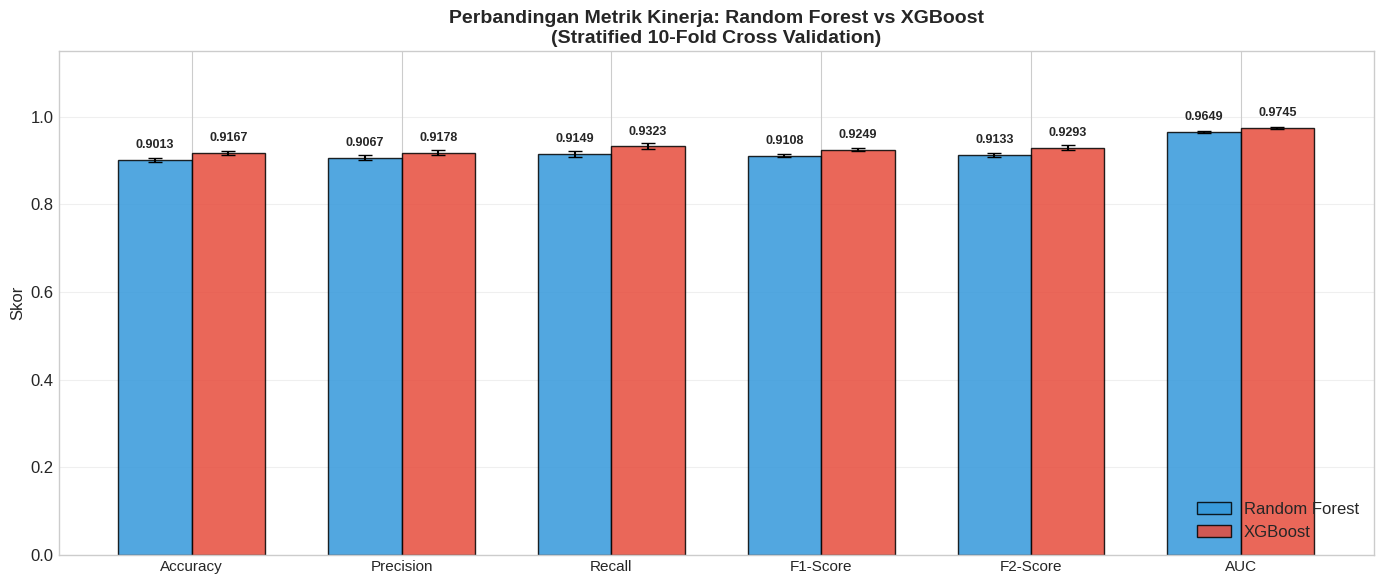

In [24]:
# ============================================
# 11.2 Grouped Bar Chart Perbandingan Metrik
# ============================================
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(metrics_labels))
width = 0.35

rf_means = [np.mean(rf_metrics[m]) for m in metrics_list]
xgb_means = [np.mean(xgb_metrics[m]) for m in metrics_list]
rf_stds = [np.std(rf_metrics[m]) for m in metrics_list]
xgb_stds = [np.std(xgb_metrics[m]) for m in metrics_list]

bars1 = ax.bar(x - width/2, rf_means, width, yerr=rf_stds, label='Random Forest',
               color='#3498db', edgecolor='black', alpha=0.85, capsize=5)
bars2 = ax.bar(x + width/2, xgb_means, width, yerr=xgb_stds, label='XGBoost',
               color='#e74c3c', edgecolor='black', alpha=0.85, capsize=5)

ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Perbandingan Metrik Kinerja: Random Forest vs XGBoost\n(Stratified 10-Fold Cross Validation)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.legend(fontsize=12, loc='lower right')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

# Tambahkan nilai di atas bar
for bar, val in zip(bars1, rf_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, xgb_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


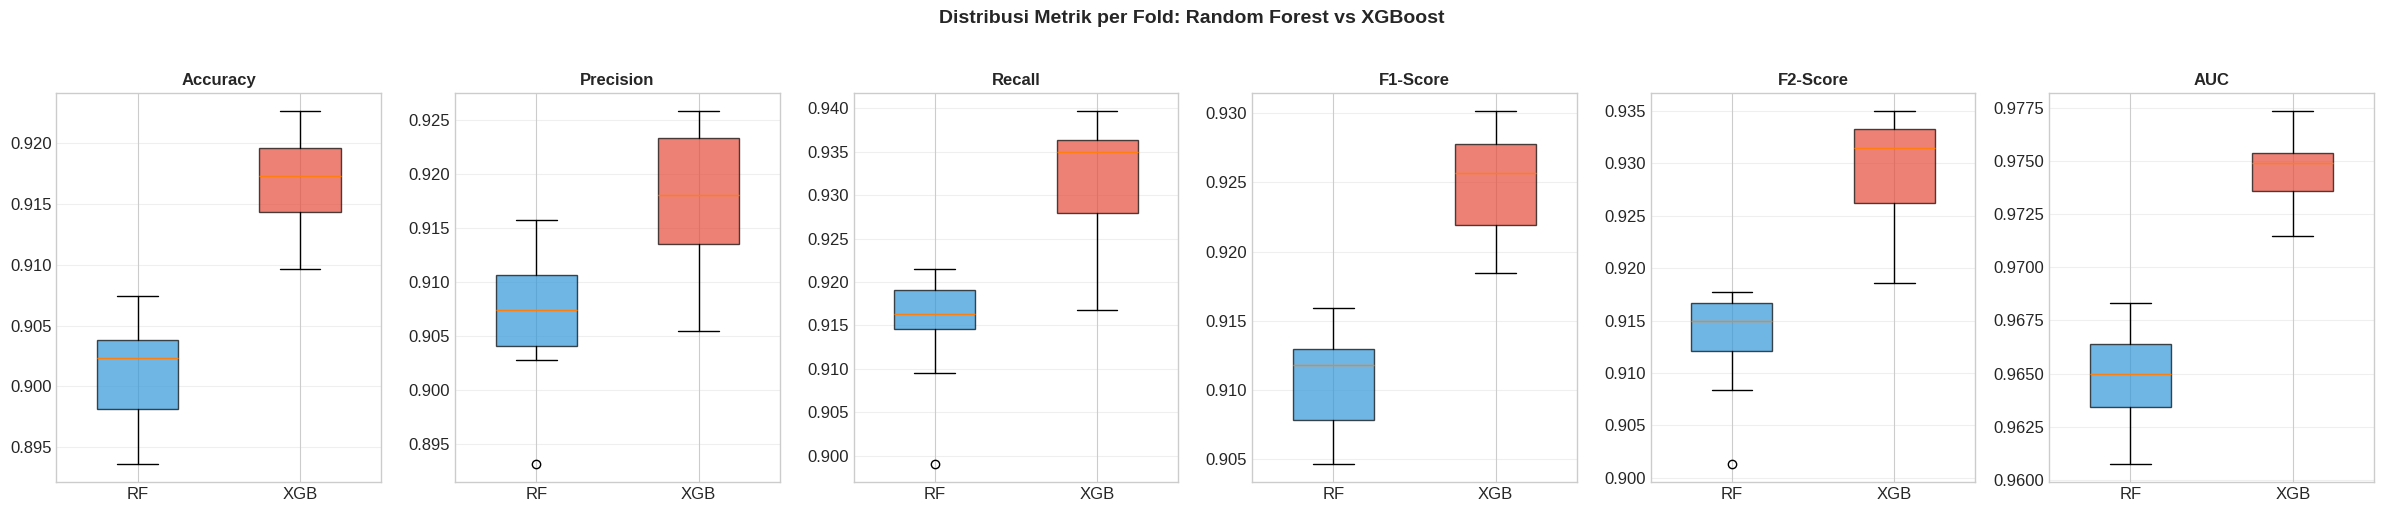

In [25]:
# ============================================
# 11.3 Boxplot Distribusi Metrik per Fold
# ============================================
fig, axes = plt.subplots(1, len(metrics_list), figsize=(24, 5))

for i, (metric, label) in enumerate(zip(metrics_list, metrics_labels)):
    data_to_plot = [rf_metrics[metric], xgb_metrics[metric]]
    ax = axes[i] if len(metrics_list) > 1 else axes
    bp = ax.boxplot(data_to_plot, labels=['RF', 'XGB'], patch_artist=True,
                     widths=0.5)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for box in bp['boxes']:
        box.set_alpha(0.7)
        box.set_edgecolor('black')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribusi Metrik per Fold: Random Forest vs XGBoost',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 12. Analisis Feature Importance - Random Forest

Feature importance pada Random Forest dihitung berdasarkan **Mean Decrease in Impurity (MDI)**, yaitu seberapa besar kontribusi rata-rata setiap fitur dalam mengurangi impurity (Gini) di seluruh pohon dalam forest.


🌲 FEATURE IMPORTANCE - RANDOM FOREST
 Ranking                                Fitur  Importance  Importance (%)
       1                          skor_kredit    0.247027           24.70
       2     rasio_hutang_terhadap_pendapatan    0.182886           18.29
       3                           suku_bunga    0.070935            7.09
       4            lama_riwayat_kredit_tahun    0.058728            5.87
       5              tunggakan_2thn_terakhir    0.055491            5.55
       6                                 usia    0.042031            4.20
       7   rasio_pinjaman_terhadap_pendapatan    0.041203            4.12
       8 rasio_pembayaran_terhadap_pendapatan    0.037682            3.77
       9                   lama_bekerja_tahun    0.032938            3.29
      10                      hutang_saat_ini    0.029956            3.00
      11                        aset_tabungan    0.028530            2.85
      12           tujuan_pinjaman_Pendidikan    0.024387            2.44
 

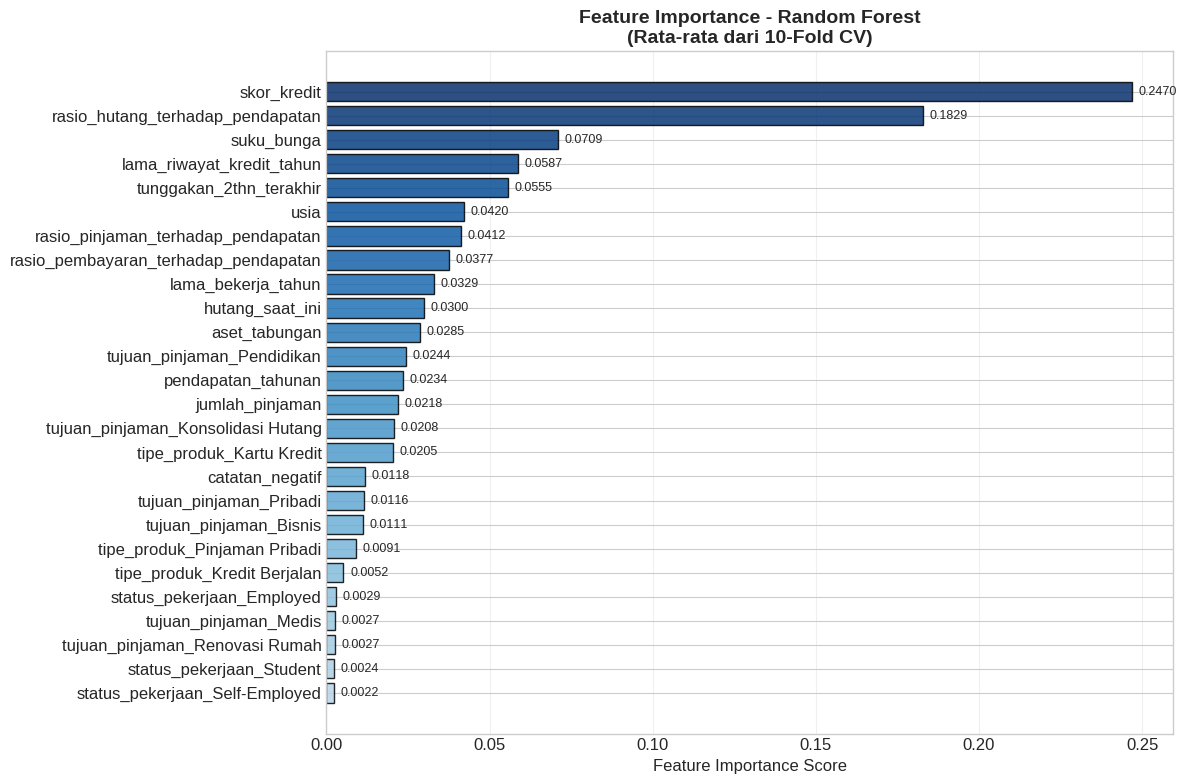

In [26]:
# ============================================
# 12. Feature Importance - Random Forest
# ============================================
print("🌲 FEATURE IMPORTANCE - RANDOM FOREST")
print("=" * 60)

# Buat DataFrame feature importance
rf_fi_df = pd.DataFrame({
    'Fitur': feature_names,
    'Importance': rf_avg_importance
}).sort_values('Importance', ascending=False).reset_index(drop=True)

rf_fi_df['Ranking'] = range(1, len(rf_fi_df) + 1)
rf_fi_df['Importance (%)'] = (rf_fi_df['Importance'] / rf_fi_df['Importance'].sum() * 100).round(2)

print(rf_fi_df[['Ranking', 'Fitur', 'Importance', 'Importance (%)']].to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 8))

rf_fi_sorted = rf_fi_df.sort_values('Importance', ascending=True)
colors = plt.cm.Blues(np.linspace(0.3, 1, len(rf_fi_sorted)))

bars = ax.barh(rf_fi_sorted['Fitur'], rf_fi_sorted['Importance'],
               color=colors, edgecolor='black', alpha=0.85)

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Feature Importance - Random Forest\n(Rata-rata dari 10-Fold CV)',
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Tambahkan nilai
for bar, val in zip(bars, rf_fi_sorted['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 13. Analisis Feature Importance - XGBoost

Feature importance pada XGBoost dihitung berdasarkan **gain**, yaitu rata-rata peningkatan performa (pengurangan loss) yang dihasilkan oleh fitur tersebut setiap kali digunakan untuk splitting.


🚀 FEATURE IMPORTANCE - XGBOOST
 Ranking                                Fitur  Importance  Importance (%)
       1                          skor_kredit    0.152746           15.27
       2     rasio_hutang_terhadap_pendapatan    0.104142           10.41
       3             tipe_produk_Kartu Kredit    0.072864            7.29
       4              tunggakan_2thn_terakhir    0.067533            6.75
       5            lama_riwayat_kredit_tahun    0.053375            5.34
       6              tujuan_pinjaman_Pribadi    0.051528            5.15
       7           tujuan_pinjaman_Pendidikan    0.049686            4.97
       8   tujuan_pinjaman_Konsolidasi Hutang    0.049249            4.92
       9 rasio_pembayaran_terhadap_pendapatan    0.048514            4.85
      10                                 usia    0.047078            4.71
      11               tujuan_pinjaman_Bisnis    0.044023            4.40
      12                           suku_bunga    0.040812            4.08
      1

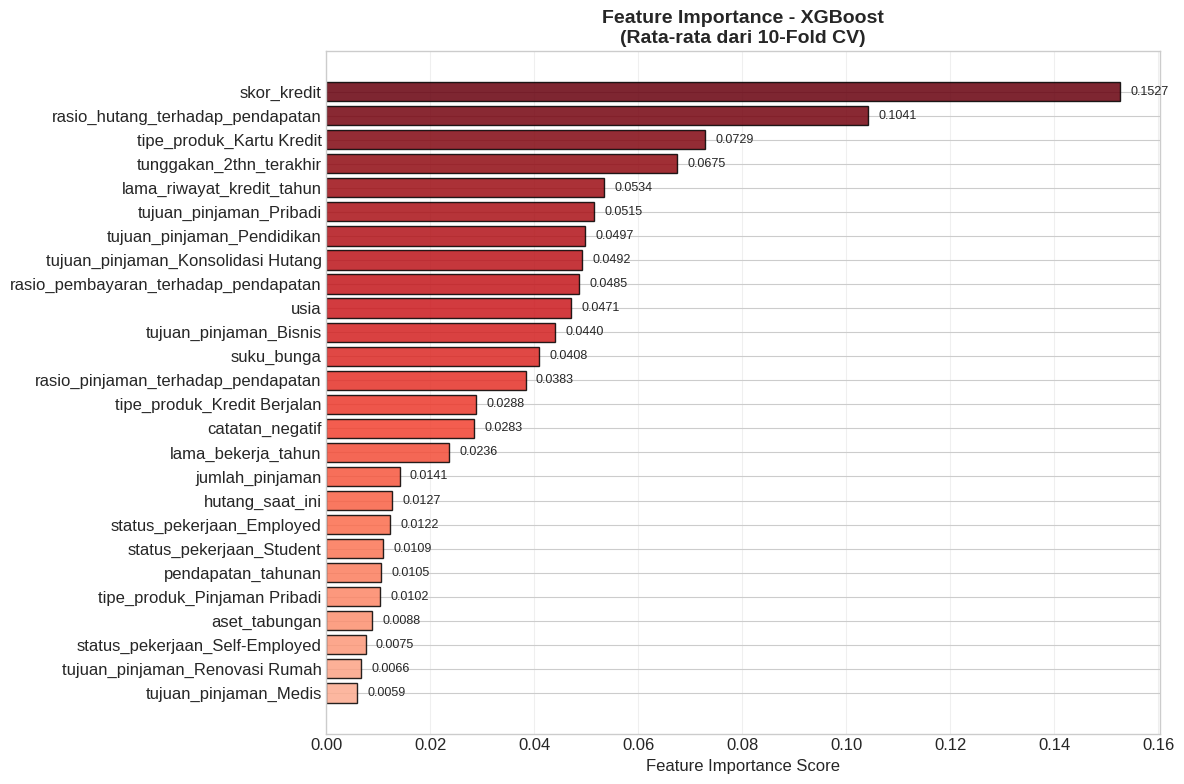

In [27]:
# ============================================
# 13. Feature Importance - XGBoost
# ============================================
print("🚀 FEATURE IMPORTANCE - XGBOOST")
print("=" * 60)

# Buat DataFrame feature importance
xgb_fi_df = pd.DataFrame({
    'Fitur': feature_names,
    'Importance': xgb_avg_importance
}).sort_values('Importance', ascending=False).reset_index(drop=True)

xgb_fi_df['Ranking'] = range(1, len(xgb_fi_df) + 1)
xgb_fi_df['Importance (%)'] = (xgb_fi_df['Importance'] / xgb_fi_df['Importance'].sum() * 100).round(2)

print(xgb_fi_df[['Ranking', 'Fitur', 'Importance', 'Importance (%)']].to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 8))

xgb_fi_sorted = xgb_fi_df.sort_values('Importance', ascending=True)
colors = plt.cm.Reds(np.linspace(0.3, 1, len(xgb_fi_sorted)))

bars = ax.barh(xgb_fi_sorted['Fitur'], xgb_fi_sorted['Importance'],
               color=colors, edgecolor='black', alpha=0.85)

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Feature Importance - XGBoost\n(Rata-rata dari 10-Fold CV)',
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, xgb_fi_sorted['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 14. Perbandingan Feature Importance Kedua Model

Membandingkan ranking feature importance dari Random Forest dan XGBoost secara side-by-side untuk mengidentifikasi fitur yang konsisten penting di kedua model.


📊 PERBANDINGAN RANKING FEATURE IMPORTANCE
                               Fitur  RF Rank  RF Importance  XGB Rank  XGB Importance  Selisih Rank
                         skor_kredit        1       0.247027         1        0.152746             0
    rasio_hutang_terhadap_pendapatan        2       0.182886         2        0.104142             0
                          suku_bunga        3       0.070935        12        0.040812             9
           lama_riwayat_kredit_tahun        4       0.058728         5        0.053375             1
             tunggakan_2thn_terakhir        5       0.055491         4        0.067533             1
                                usia        6       0.042031        10        0.047078             4
  rasio_pinjaman_terhadap_pendapatan        7       0.041203        13        0.038302             6
rasio_pembayaran_terhadap_pendapatan        8       0.037682         9        0.048514             1
                  lama_bekerja_tahun        9    

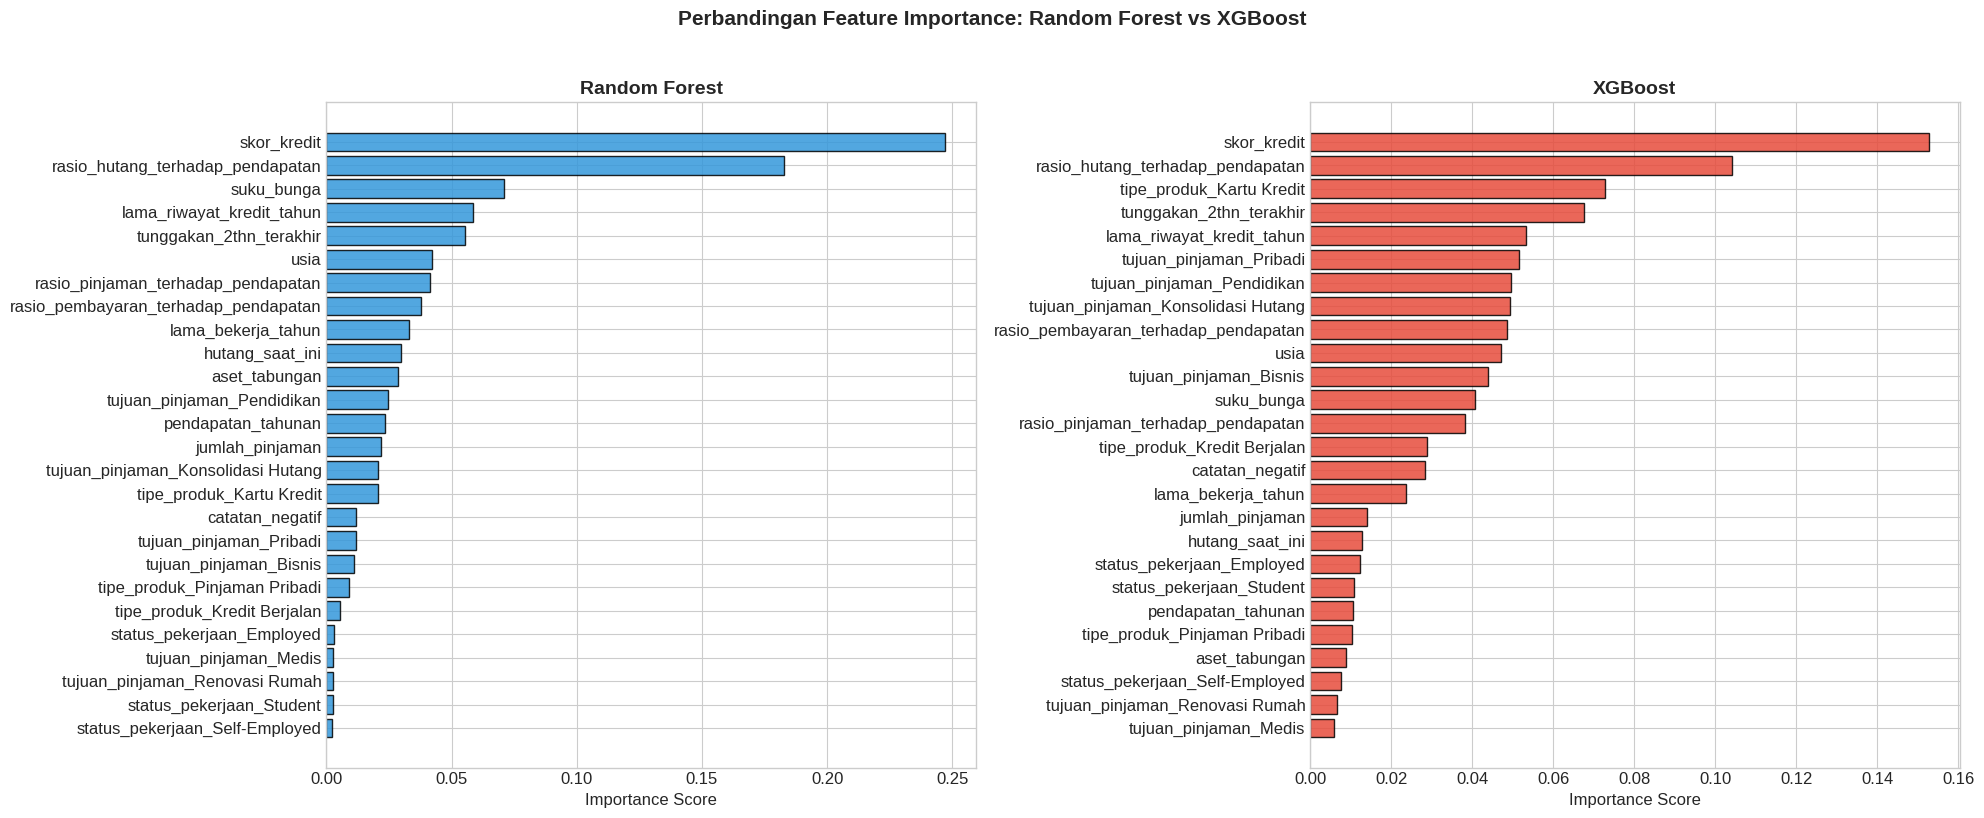


🔑 Top 5 Fitur Random Forest  : {'tunggakan_2thn_terakhir', 'suku_bunga', 'rasio_hutang_terhadap_pendapatan', 'skor_kredit', 'lama_riwayat_kredit_tahun'}
🔑 Top 5 Fitur XGBoost        : {'tunggakan_2thn_terakhir', 'tipe_produk_Kartu Kredit', 'rasio_hutang_terhadap_pendapatan', 'skor_kredit', 'lama_riwayat_kredit_tahun'}
✅ Fitur Konsisten Penting     : {'rasio_hutang_terhadap_pendapatan', 'tunggakan_2thn_terakhir', 'skor_kredit', 'lama_riwayat_kredit_tahun'}


In [28]:
# ============================================
# 14. Perbandingan Feature Importance
# ============================================
print("📊 PERBANDINGAN RANKING FEATURE IMPORTANCE")
print("=" * 70)

# Buat tabel ranking perbandingan
ranking_comparison = pd.DataFrame({
    'Fitur': feature_names,
    'RF Importance': rf_avg_importance,
    'XGB Importance': xgb_avg_importance
})

# Hitung ranking
ranking_comparison['RF Rank'] = ranking_comparison['RF Importance'].rank(ascending=False).astype(int)
ranking_comparison['XGB Rank'] = ranking_comparison['XGB Importance'].rank(ascending=False).astype(int)
ranking_comparison['Selisih Rank'] = abs(ranking_comparison['RF Rank'] - ranking_comparison['XGB Rank'])
ranking_comparison = ranking_comparison.sort_values('RF Rank')

print(ranking_comparison[['Fitur', 'RF Rank', 'RF Importance', 'XGB Rank', 'XGB Importance', 'Selisih Rank']].to_string(index=False))

# Visualisasi side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Random Forest
rf_sorted = ranking_comparison.sort_values('RF Importance', ascending=True)
axes[0].barh(rf_sorted['Fitur'], rf_sorted['RF Importance'],
             color='#3498db', edgecolor='black', alpha=0.85)
axes[0].set_title('Random Forest', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance Score')

# XGBoost
xgb_sorted = ranking_comparison.sort_values('XGB Importance', ascending=True)
axes[1].barh(xgb_sorted['Fitur'], xgb_sorted['XGB Importance'],
             color='#e74c3c', edgecolor='black', alpha=0.85)
axes[1].set_title('XGBoost', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Perbandingan Feature Importance: Random Forest vs XGBoost',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Fitur konsisten penting (top 5 di kedua model)
rf_top5 = set(ranking_comparison.nsmallest(5, 'RF Rank')['Fitur'])
xgb_top5 = set(ranking_comparison.nsmallest(5, 'XGB Rank')['Fitur'])
consistent_top = rf_top5.intersection(xgb_top5)

print(f"\n🔑 Top 5 Fitur Random Forest  : {rf_top5}")
print(f"🔑 Top 5 Fitur XGBoost        : {xgb_top5}")
print(f"✅ Fitur Konsisten Penting     : {consistent_top if consistent_top else 'Tidak ada'}")


## 15. Visualisasi Confusion Matrix Kedua Model

Confusion matrix menunjukkan distribusi prediksi benar dan salah untuk setiap kelas, membantu mengidentifikasi tipe kesalahan yang paling sering terjadi di masing-masing model.


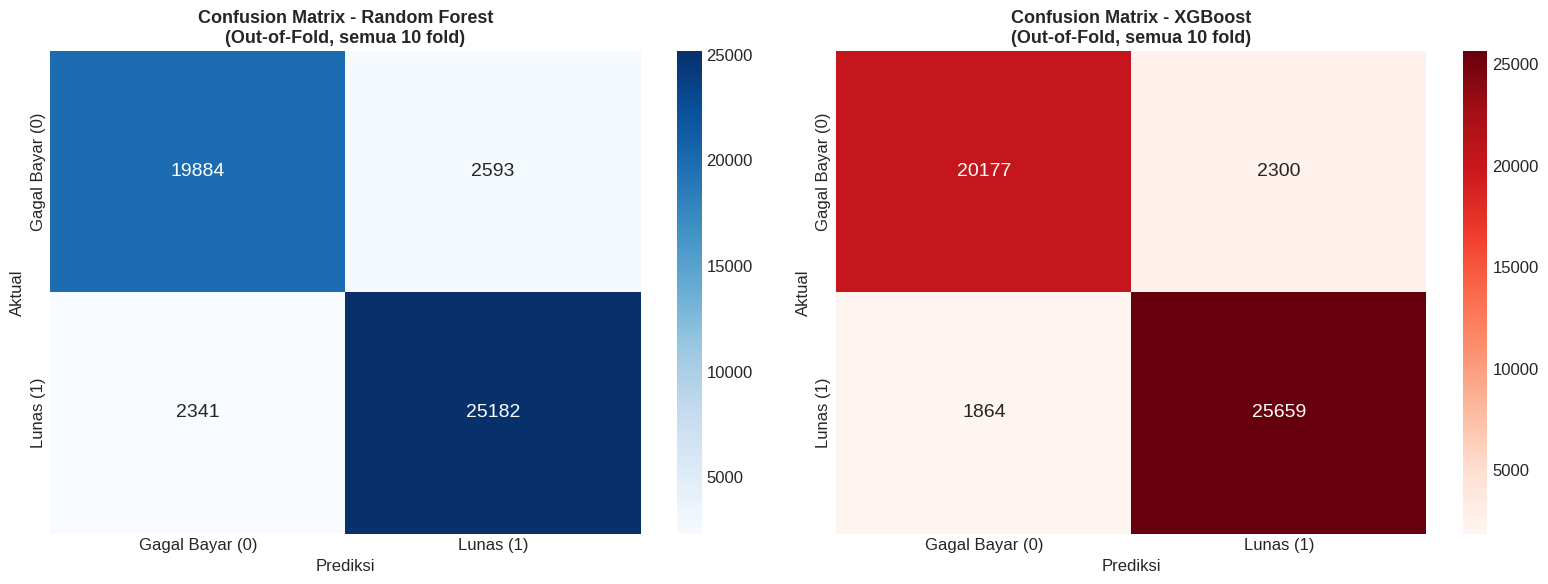


📊 Detail Confusion Matrix (OOF — semua fold digabung):

  Random Forest:
    True Negative  (TN) : 19,884 → Benar prediksi Gagal Bayar
    True Positive  (TP) : 25,182 → Benar prediksi Lunas
    False Positive (FP) : 2,593 → Salah prediksi Lunas (padahal Gagal Bayar)
    False Negative (FN) : 2,341 → Salah prediksi Gagal Bayar (padahal Lunas)

  XGBoost:
    True Negative  (TN) : 20,177 → Benar prediksi Gagal Bayar
    True Positive  (TP) : 25,659 → Benar prediksi Lunas
    False Positive (FP) : 2,300 → Salah prediksi Lunas (padahal Gagal Bayar)
    False Negative (FN) : 1,864 → Salah prediksi Gagal Bayar (padahal Lunas)

💰 Estimasi Kerugian Finansial (OOF — asumsi konsisten):
   FP: (1 - recovery_rate) × loan = Rp 23,129/kasus
   FN: profit_margin × loan       = Rp 1,652/kasus

  Random Forest:
    FP (diprediksi Lunas, nyatanya Gagal Bayar) : 2,593 → Rp 59,974,534
    FN (diprediksi Gagal Bayar, nyatanya Lunas)  : 2,341 → Rp 3,867,566
    Total estimasi kerugian                     

In [29]:
# ============================================
# 15. Confusion Matrix Kedua Model (Out-of-Fold)
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix - Random Forest (OOF)
cm_rf = confusion_matrix(rf_oof_y_true, rf_oof_y_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Gagal Bayar (0)', 'Lunas (1)'],
            yticklabels=['Gagal Bayar (0)', 'Lunas (1)'],
            annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix - Random Forest\n(Out-of-Fold, semua 10 fold)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Aktual', fontsize=12)
axes[0].set_xlabel('Prediksi', fontsize=12)

# Confusion Matrix - XGBoost (OOF)
cm_xgb = confusion_matrix(xgb_oof_y_true, xgb_oof_y_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Gagal Bayar (0)', 'Lunas (1)'],
            yticklabels=['Gagal Bayar (0)', 'Lunas (1)'],
            annot_kws={'size': 14})
axes[1].set_title('Confusion Matrix - XGBoost\n(Out-of-Fold, semua 10 fold)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Aktual', fontsize=12)
axes[1].set_xlabel('Prediksi', fontsize=12)

plt.tight_layout()
plt.show()

# Detail angka
print("\n📊 Detail Confusion Matrix (OOF — semua fold digabung):")
print("=" * 60)
for name, cm in [('Random Forest', cm_rf), ('XGBoost', cm_xgb)]:
    tn, fp, fn, tp = cm.ravel()
    print(f"\n  {name}:")
    print(f"    True Negative  (TN) : {tn:,} → Benar prediksi Gagal Bayar")
    print(f"    True Positive  (TP) : {tp:,} → Benar prediksi Lunas")
    print(f"    False Positive (FP) : {fp:,} → Salah prediksi Lunas (padahal Gagal Bayar)")
    print(f"    False Negative (FN) : {fn:,} → Salah prediksi Gagal Bayar (padahal Lunas)")

# Estimasi kerugian finansial (pakai asumsi yang sama dengan Step 9.1 & 10.1)
print("\n💰 Estimasi Kerugian Finansial (OOF — asumsi konsisten):")
print(f"   FP: (1 - recovery_rate) × loan = Rp {loss_per_fp:,.0f}/kasus")
print(f"   FN: profit_margin × loan       = Rp {cost_per_fn:,.0f}/kasus")

def estimate_loss_oof(model_name, y_true_list, y_pred_list):
    y_true_arr = np.array(y_true_list)
    y_pred_arr = np.array(y_pred_list)
    fp_count = int(((y_true_arr == 0) & (y_pred_arr == 1)).sum())
    fn_count = int(((y_true_arr == 1) & (y_pred_arr == 0)).sum())
    loss_fp = fp_count * loss_per_fp   # konsisten dengan Step 9.1
    loss_fn = fn_count * cost_per_fn   # konsisten dengan Step 9.1
    total   = loss_fp + loss_fn
    print(f"\n  {model_name}:")
    print(f"    FP (diprediksi Lunas, nyatanya Gagal Bayar) : {fp_count:,} → Rp {loss_fp:,.0f}")
    print(f"    FN (diprediksi Gagal Bayar, nyatanya Lunas)  : {fn_count:,} → Rp {loss_fn:,.0f}")
    print(f"    Total estimasi kerugian                      : Rp {total:,.0f}")

estimate_loss_oof('Random Forest', rf_oof_y_true, rf_oof_y_pred)
estimate_loss_oof('XGBoost',       xgb_oof_y_true, xgb_oof_y_pred)


## 16. Visualisasi ROC Curve dan AUC Score Kedua Model

ROC Curve (Receiver Operating Characteristic) menggambarkan kemampuan diskriminasi model pada berbagai threshold. **AUC** (Area Under Curve) yang lebih tinggi menunjukkan model yang lebih baik dalam membedakan kelas positif dan negatif.


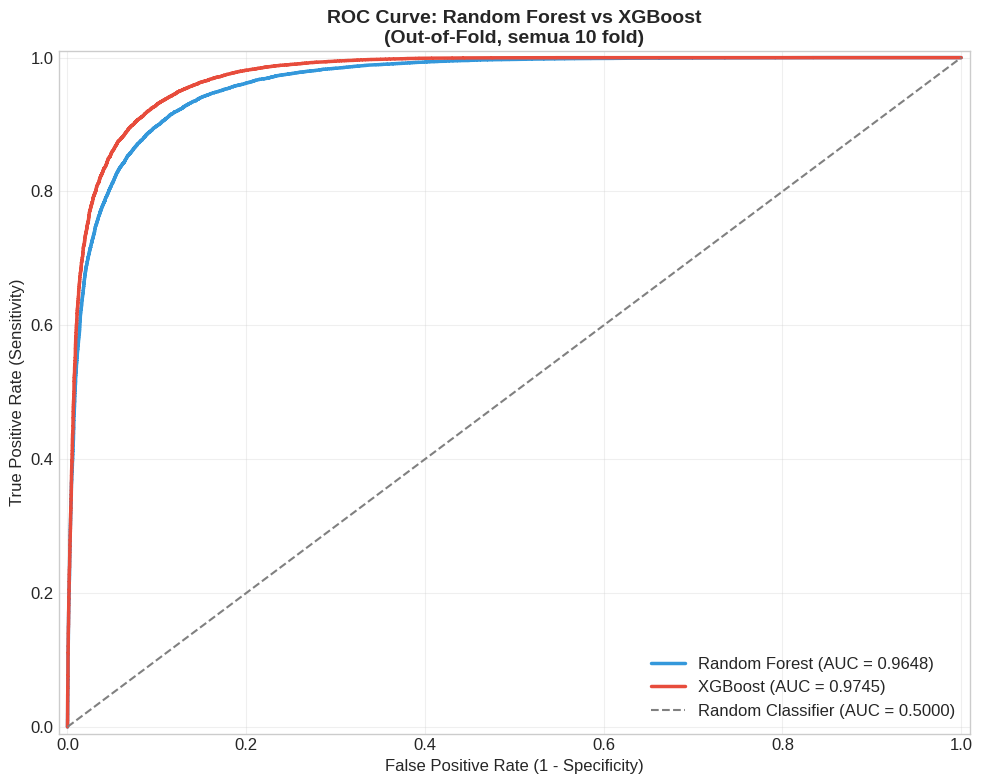


📊 Perbandingan AUC Score (OOF):
   Random Forest : 0.9648
   XGBoost       : 0.9745

   → XGBoost memiliki kemampuan diskriminasi lebih baik (+0.0096)


In [30]:
# ============================================
# 16. ROC Curve dan AUC Score (Out-of-Fold)
# ============================================
fig, ax = plt.subplots(figsize=(10, 8))

# ROC - Random Forest (OOF)
fpr_rf, tpr_rf, _ = roc_curve(rf_oof_y_true, rf_oof_y_prob)
auc_rf = roc_auc_score(rf_oof_y_true, rf_oof_y_prob)
ax.plot(fpr_rf, tpr_rf, color='#3498db', linewidth=2.5,
        label=f'Random Forest (AUC = {auc_rf:.4f})')

# ROC - XGBoost (OOF)
fpr_xgb, tpr_xgb, _ = roc_curve(xgb_oof_y_true, xgb_oof_y_prob)
auc_xgb = roc_auc_score(xgb_oof_y_true, xgb_oof_y_prob)
ax.plot(fpr_xgb, tpr_xgb, color='#e74c3c', linewidth=2.5,
        label=f'XGBoost (AUC = {auc_xgb:.4f})')

# Garis diagonal (random classifier)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5,
        label='Random Classifier (AUC = 0.5000)')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curve: Random Forest vs XGBoost\n(Out-of-Fold, semua 10 fold)',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.show()

print(f"\n📊 Perbandingan AUC Score (OOF):")
print(f"   Random Forest : {auc_rf:.4f}")
print(f"   XGBoost       : {auc_xgb:.4f}")
if auc_rf > auc_xgb:
    print(f"\n   → Random Forest memiliki kemampuan diskriminasi lebih baik (+{auc_rf-auc_xgb:.4f})")
else:
    print(f"\n   → XGBoost memiliki kemampuan diskriminasi lebih baik (+{auc_xgb-auc_rf:.4f})")


## 17. Uji Statistik Perbandingan Kinerja Model (Paired t-test)

Untuk menentukan apakah perbedaan kinerja antara kedua model **signifikan secara statistik**, dilakukan **Paired t-test** pada metrik dari setiap fold.

**Hipotesis:**
- **H₀ (Null):** Tidak ada perbedaan signifikan antara kinerja Random Forest dan XGBoost
- **H₁ (Alternatif):** Terdapat perbedaan signifikan antara kinerja Random Forest dan XGBoost
- **Significance Level (α):** 0.05


In [31]:
# ============================================
# 17. Paired t-test
# ============================================
print("📊 UJI STATISTIK: PAIRED T-TEST")
print("=" * 70)
print(f"Significance Level (α) = 0.05")
print(f"Jumlah Fold            = {N_SPLITS}")
print()

alpha = 0.05
ttest_results = []

for metric, label in zip(metrics_list, metrics_labels):
    t_stat, p_value = ttest_rel(rf_metrics[metric], xgb_metrics[metric])
    significant = "Ya ✅" if p_value < alpha else "Tidak ❌"
    decision = "Tolak H₀" if p_value < alpha else "Gagal Tolak H₀"

    ttest_results.append({
        'Metrik': label,
        't-statistic': t_stat,
        'p-value': p_value,
        'Signifikan': significant,
        'Keputusan': decision
    })

ttest_df = pd.DataFrame(ttest_results)

for _, row in ttest_df.iterrows():
    print(f"  📌 {row['Metrik']}:")
    print(f"     t-statistic = {row['t-statistic']:.4f}")
    print(f"     p-value     = {row['p-value']:.6f}")
    print(f"     Signifikan  = {row['Signifikan']}")
    print(f"     Keputusan   = {row['Keputusan']}")
    print()

print("=" * 70)
print("\n📋 Ringkasan Paired t-test:")
print(ttest_df.to_string(index=False))


📊 UJI STATISTIK: PAIRED T-TEST
Significance Level (α) = 0.05
Jumlah Fold            = 10

  📌 Accuracy:
     t-statistic = -14.2063
     p-value     = 0.000000
     Signifikan  = Ya ✅
     Keputusan   = Tolak H₀

  📌 Precision:
     t-statistic = -8.0326
     p-value     = 0.000021
     Signifikan  = Ya ✅
     Keputusan   = Tolak H₀

  📌 Recall:
     t-statistic = -15.4385
     p-value     = 0.000000
     Signifikan  = Ya ✅
     Keputusan   = Tolak H₀

  📌 F1-Score:
     t-statistic = -14.7814
     p-value     = 0.000000
     Signifikan  = Ya ✅
     Keputusan   = Tolak H₀

  📌 F2-Score:
     t-statistic = -16.4319
     p-value     = 0.000000
     Signifikan  = Ya ✅
     Keputusan   = Tolak H₀

  📌 AUC:
     t-statistic = -23.1421
     p-value     = 0.000000
     Signifikan  = Ya ✅
     Keputusan   = Tolak H₀


📋 Ringkasan Paired t-test:
   Metrik  t-statistic      p-value Signifikan Keputusan
 Accuracy   -14.206309 1.807185e-07       Ya ✅  Tolak H₀
Precision    -8.032609 2.142669e-05  

## 18. Kesimpulan


In [32]:
# ============================================
# 18. Kesimpulan Akhir
# ============================================
print("=" * 70)
print("📝 KESIMPULAN AKHIR")
print("=" * 70)

print(f"\n1️⃣  DATASET:")
print(f"   - Total data: {len(X):,} sampel")
print(f"   - Fitur asli (sebelum OHE) : 17 kolom")
print(f"   - Fitur setelah preprocessing (OHE) : {len(feature_names)} fitur")
print(f"     (3 kolom kategorikal → {len(feature_names) - (17-2-1-3)} kolom OHE baru)")
print(f"   - Kolom di-drop: 'id_pelanggan' (ID) & 'gagal_bayar_tercatat' (leakage)")
print(f"   - Target: status_pinjaman (0=Gagal Bayar, 1=Lunas)")

print(f"\n2️⃣  KESEIMBANGAN DATA:")
print(f"   - Kelas 0 (Gagal Bayar): {kelas_0:,} ({kelas_0/total*100:.1f}%)")
print(f"   - Kelas 1 (Lunas)      : {kelas_1:,} ({kelas_1/total*100:.1f}%)")
print(f"   - Imbalance Ratio      : 1:{imbalance_ratio:.2f}")
print(f"   - Penanganan           : SMOTE pada data training setiap fold")

print(f"\n3️⃣  PERBANDINGAN KINERJA (Stratified {N_SPLITS}-Fold CV):")
print(f"   {'Metrik':<12} {'Random Forest':>15} {'XGBoost':>15} {'Unggul':>15}")
print(f"   {'-'*57}")
for metric, label in zip(metrics_list, metrics_labels):
    rf_m = np.mean(rf_metrics[metric])
    xgb_m = np.mean(xgb_metrics[metric])
    winner = 'RF' if rf_m > xgb_m else 'XGB' if xgb_m > rf_m else 'Seri'
    print(f"   {label:<12} {rf_m:>15.4f} {xgb_m:>15.4f} {winner:>15}")

print(f"\n4️⃣  UJI STATISTIK (Paired t-test, α=0.05):")
for _, row in ttest_df.iterrows():
    print(f"   {row['Metrik']:<12}: p-value = {row['p-value']:.6f} → {row['Keputusan']}")

print(f"\n5️⃣  FEATURE IMPORTANCE:")
rf_top3 = rf_fi_df.nsmallest(3, 'Ranking')['Fitur'].tolist()
xgb_top3 = xgb_fi_df.nsmallest(3, 'Ranking')['Fitur'].tolist()
print(f"   Top 3 RF  : {', '.join(rf_top3)}")
print(f"   Top 3 XGB : {', '.join(xgb_top3)}")

print(f"\n{'='*70}")
# Tentukan model terbaik berdasarkan F1-Score rata-rata
rf_f1_mean = np.mean(rf_metrics['f1_score'])
xgb_f1_mean = np.mean(xgb_metrics['f1_score'])
if rf_f1_mean > xgb_f1_mean:
    best_model = "Random Forest"
    best_f1 = rf_f1_mean
else:
    best_model = "XGBoost"
    best_f1 = xgb_f1_mean

print(f"\n🏆 MODEL TERBAIK: {best_model} (F1-Score rata-rata: {best_f1:.4f})")
print(f"\n{'='*70}")


📝 KESIMPULAN AKHIR

1️⃣  DATASET:
   - Total data: 50,000 sampel
   - Fitur asli (sebelum OHE) : 17 kolom
   - Fitur setelah preprocessing (OHE) : 26 fitur
     (3 kolom kategorikal → 15 kolom OHE baru)
   - Kolom di-drop: 'id_pelanggan' (ID) & 'gagal_bayar_tercatat' (leakage)
   - Target: status_pinjaman (0=Gagal Bayar, 1=Lunas)

2️⃣  KESEIMBANGAN DATA:
   - Kelas 0 (Gagal Bayar): 22,477 (45.0%)
   - Kelas 1 (Lunas)      : 27,523 (55.0%)
   - Imbalance Ratio      : 1:1.22
   - Penanganan           : SMOTE pada data training setiap fold

3️⃣  PERBANDINGAN KINERJA (Stratified 10-Fold CV):
   Metrik         Random Forest         XGBoost          Unggul
   ---------------------------------------------------------
   Accuracy              0.9013          0.9167             XGB
   Precision             0.9067          0.9178             XGB
   Recall                0.9149          0.9323             XGB
   F1-Score              0.9108          0.9249             XGB
   F2-Score             

## 19. Validasi Anti-Leakage Tambahan (Preprocessing per Fold + Label Shuffle Test)

Bagian ini menjalankan evaluasi leakage-safe dengan aturan lebih ketat:
- Data mentah di-load ulang khusus untuk modeling.
- Imputasi dan encoding di-fit hanya pada data training di setiap fold.
- SMOTE tetap hanya diterapkan pada data training fold.
- Ditambahkan **label shuffle test**: jika pipeline bersih, AUC seharusnya mendekati 0.5.

In [33]:
# ============================================
# 19.1 Evaluasi No-Leakage (Preprocessing per Fold)
# ============================================
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import clone

print("🔒 VALIDASI ANTI-LEAKAGE: PREPROCESSING PER FOLD")
print("=" * 70)

# Reload data mentah untuk evaluasi leakage-safe
df_raw = pd.read_csv('data/loan_data.csv')

# Drop kolom non-prediktif dan leakage eksplisit
df_model = df_raw.drop(columns=['id_pelanggan', 'gagal_bayar_tercatat'])

X_nl = df_model.drop('status_pinjaman', axis=1)
y_nl = df_model['status_pinjaman']

num_cols_nl = X_nl.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_nl = X_nl.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Jumlah fitur numerik     : {len(num_cols_nl)}")
print(f"Jumlah fitur kategorikal : {len(cat_cols_nl)}")
print(f"Total fitur              : {X_nl.shape[1]}")
print(f"Total sampel             : {len(X_nl):,}")


def preprocess_fold_no_leakage(X_train, X_val, num_cols, cat_cols):
    X_train_proc = X_train.copy()
    X_val_proc = X_val.copy()

    if num_cols:
        num_imputer = SimpleImputer(strategy='median')
        X_train_proc[num_cols] = num_imputer.fit_transform(X_train[num_cols])
        X_val_proc[num_cols] = num_imputer.transform(X_val[num_cols])

    if cat_cols:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        X_train_cat = cat_imputer.fit_transform(X_train[cat_cols])
        X_val_cat = cat_imputer.transform(X_val[cat_cols])

        cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        X_train_ohe = cat_encoder.fit_transform(X_train_cat)
        X_val_ohe = cat_encoder.transform(X_val_cat)

        ohe_cols = cat_encoder.get_feature_names_out(cat_cols)
        X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_cols, index=X_train.index)
        X_val_ohe_df = pd.DataFrame(X_val_ohe, columns=ohe_cols, index=X_val.index)

        X_train_proc = X_train_proc.drop(columns=cat_cols)
        X_val_proc = X_val_proc.drop(columns=cat_cols)
        X_train_proc = pd.concat([X_train_proc, X_train_ohe_df], axis=1)
        X_val_proc = pd.concat([X_val_proc, X_val_ohe_df], axis=1)

    return X_train_proc.astype(float), X_val_proc.astype(float)


def cv_auc_no_leakage(X, y, model, n_splits=10, random_state=42, use_smote=True):
    skf_local = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    smote_local = SMOTE(random_state=random_state)
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(skf_local.split(X, y), 1):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        X_train_proc, X_val_proc = preprocess_fold_no_leakage(
            X_train_fold, X_val_fold, num_cols_nl, cat_cols_nl
        )

        if use_smote:
            X_train_proc, y_train_fold = smote_local.fit_resample(X_train_proc, y_train_fold)

        model_fold = clone(model)
        model_fold.fit(X_train_proc, y_train_fold)
        y_prob = model_fold.predict_proba(X_val_proc)[:, 1]

        auc_fold = roc_auc_score(y_val_fold, y_prob)
        fold_aucs.append(auc_fold)

    return np.array(fold_aucs)


rf_base = RandomForestClassifier(**rf_params_repr)
xgb_base = XGBClassifier(**xgb_params_repr)

rf_auc_nl = cv_auc_no_leakage(
    X_nl, y_nl, rf_base, n_splits=N_SPLITS, random_state=42, use_smote=True
)
xgb_auc_nl = cv_auc_no_leakage(
    X_nl, y_nl, xgb_base, n_splits=N_SPLITS, random_state=42, use_smote=True
)

print("\n📊 AUC No-Leakage (preprocessing fit di TRAIN fold):")
print(f"   Random Forest : {rf_auc_nl.mean():.4f} ± {rf_auc_nl.std():.4f}")
print(f"   XGBoost       : {xgb_auc_nl.mean():.4f} ± {xgb_auc_nl.std():.4f}")

if 'rf_metrics' in globals() and 'xgb_metrics' in globals():
    print("\n🔍 Perbandingan dengan setup sebelumnya:")
    print(f"   RF  sebelumnya: {np.mean(rf_metrics['auc']):.4f} ± {np.std(rf_metrics['auc']):.4f}")
    print(f"   RF  no-leakage: {rf_auc_nl.mean():.4f} ± {rf_auc_nl.std():.4f}")
    print(f"   XGB sebelumnya: {np.mean(xgb_metrics['auc']):.4f} ± {np.std(xgb_metrics['auc']):.4f}")
    print(f"   XGB no-leakage: {xgb_auc_nl.mean():.4f} ± {xgb_auc_nl.std():.4f}")


🔒 VALIDASI ANTI-LEAKAGE: PREPROCESSING PER FOLD
Jumlah fitur numerik     : 14
Jumlah fitur kategorikal : 3
Total fitur              : 17
Total sampel             : 50,000

📊 AUC No-Leakage (preprocessing fit di TRAIN fold):
   Random Forest : 0.9653 ± 0.0023
   XGBoost       : 0.9746 ± 0.0015

🔍 Perbandingan dengan setup sebelumnya:
   RF  sebelumnya: 0.9649 ± 0.0023
   RF  no-leakage: 0.9653 ± 0.0023
   XGB sebelumnya: 0.9745 ± 0.0018
   XGB no-leakage: 0.9746 ± 0.0015


In [34]:
# ============================================
# 19.2 Label Shuffle Test (Sanity Check Leakage)
# ============================================
print("🧪 LABEL SHUFFLE TEST (sanity check)")
print("=" * 70)

rng = np.random.default_rng(42)
y_shuffled = pd.Series(rng.permutation(y_nl.values), index=y_nl.index)

# Gunakan 5-fold agar pengecekan lebih cepat
rf_auc_shuffle = cv_auc_no_leakage(
    X_nl, y_shuffled, rf_base, n_splits=5, random_state=42, use_smote=False
)
xgb_auc_shuffle = cv_auc_no_leakage(
    X_nl, y_shuffled, xgb_base, n_splits=5, random_state=42, use_smote=False
)

print(f"RF  shuffled-label AUC : {rf_auc_shuffle.mean():.4f} ± {rf_auc_shuffle.std():.4f}")
print(f"XGB shuffled-label AUC : {xgb_auc_shuffle.mean():.4f} ± {xgb_auc_shuffle.std():.4f}")
print("Expected baseline      : ~0.5000")

for model_name, auc_val in [('RF', rf_auc_shuffle.mean()), ('XGB', xgb_auc_shuffle.mean())]:
    if 0.45 <= auc_val <= 0.55:
        print(f"✅ {model_name}: mendekati 0.5 → tidak ada sinyal leakage yang jelas.")
    else:
        print(f"⚠️ {model_name}: jauh dari 0.5 → perlu audit pipeline/fitur lebih lanjut.")

🧪 LABEL SHUFFLE TEST (sanity check)
RF  shuffled-label AUC : 0.5025 ± 0.0065
XGB shuffled-label AUC : 0.5005 ± 0.0038
Expected baseline      : ~0.5000
✅ RF: mendekati 0.5 → tidak ada sinyal leakage yang jelas.
✅ XGB: mendekati 0.5 → tidak ada sinyal leakage yang jelas.
